# Canonical Correlation Analysis (CCA) for Neural Data

This notebook performs CCA to assess correlations between different brain areas during different task epochs, following a PCA-CCA pipeline with bootstrap testing and subspace comparison.

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import CCA

# For data loading from existing pipeline
import npc_lims
from dynamic_routing_analysis import spike_utils
from dynamic_routing_analysis import data_utils

%load_ext autoreload
%autoreload 2

## 2. Load and Prepare Neural Data

In [2]:
# Load session data
# session_id = "664851_2023-11-13"  # mediocre DR session 
session_id = "742903_2024-10-22"  # good DR session 

session_info = npc_lims.get_session_info(session_id)
trials = data_utils.load_trials_or_units(session_info, 'trials', version='0.0.272')
units = data_utils.load_trials_or_units(session_info, 'units', version='0.0.272')

# Filter units with quality criteria
units_filtered = units.query(
    'presence_ratio>=0.7 and \
    isi_violations_ratio<=0.5 and \
    amplitude_cutoff<=0.1 and \
    activity_drift<=0.1 and \
    firing_rate>=0.1 and \
    ~structure.isna() and ~location.isna()'
).sort_values(['electrode_group_name', 'peak_channel', 'unit_id'])

print(f"Total filtered units: {len(units_filtered)}")
print(f"Structures represented: {units_filtered['structure'].unique()}")

742903_2024-10-22 cached trials loaded
742903_2024-10-22 cached units loaded
Total filtered units: 1097
Structures represented: ['LSr' 'ACAv' 'PL' 'ACAd' 'MOs' 'GU' 'SSs' 'SSp' 'CP' 'CA3' 'DG' 'CA1'
 'VISal' 'TTd' 'ORBvl' 'OLF' 'ORBl' 'FRP' 'ILA' 'ORBm']


In [3]:
# Create trial data arrays for task epochs
time_before = 0.5
time_after = 0.01
binsize = 0.5

trial_da = spike_utils.make_neuron_time_trials_tensor(
    units_filtered, trials, time_before, time_after, binsize
)

print(f"Task trial data shape: {trial_da.shape}")
print(f"Dimensions: {trial_da.dims}")

Task trial data shape: (1097, 1, 538)
Dimensions: ('unit_id', 'time', 'trials')


In [4]:
# Load spontaneous data (from existing notebook logic)
epochs = pd.read_parquet(
    npc_lims.get_cache_path(nwb_component='epochs', session_id=session_id, version='0.0.272')
)

# Load rewards for spontaneous trial alignment
import lazynwb
path = 's3://aind-scratch-data/dynamic-routing/cache/nwb/v0.0.272/{session_id}.nwb'
internal_path = 'processing/behavior/rewards'
rewards = lazynwb.get_df(path.format(session_id=session_id), internal_path, as_polars=False)

print(f"Epochs available: {epochs['script_name'].unique()}")

Epochs available: ['RFMapping' 'OptoTagging' 'Spontaneous' 'SpontaneousRewards'
 'DynamicRouting1']


In [5]:
# Generate spontaneous trials using ITI distribution
def generate_DR_ITI(n_samples=None, is_templeton=False):
    import random
    
    preStimFramesFixed = 90
    preStimFramesVariableMean = 60
    preStimFramesMax = 360
    responseWindow = [6, 60]
    postResponseWindowFrames = 180
    
    if is_templeton:
        preStimFramesVariableMean = 30
        preStimFramesMax = 240
        postResponseWindowFrames = 120
    
    if n_samples is not None:
        return [generate_DR_ITI(is_templeton=is_templeton) for _ in range(n_samples)]
    else:
        val = preStimFramesFixed + random.expovariate(1/preStimFramesVariableMean) if preStimFramesVariableMean > 1 else preStimFramesFixed + preStimFramesVariableMean
        trial_total_length = (int(min(val, preStimFramesMax)) + responseWindow[1] + postResponseWindowFrames) / 60
        return trial_total_length

# Create spontaneous trial times
min_ITI = 5.5
spont_trials = {
    'start_time': [],
    'epoch_idx': [],
    'epoch_name': [],
    'is_rewarded': []
}

task_index=epochs.query('script_name=="DynamicRouting1"').index[0]

for rr, row in epochs.query('script_name=="Spontaneous" and id<@task_index').iterrows():
# for rr, row in epochs.query('script_name.str.contains("Spontaneous")').iterrows():
    spont_start = row['start_time']
    spont_end = row['stop_time']
    
    sampleITIs = generate_DR_ITI(n_samples=1000, is_templeton=False)
    cum_sampleITIs = np.cumsum(sampleITIs)
    valid_starts = spont_start + cum_sampleITIs[cum_sampleITIs + spont_start < spont_end]
    is_rewarded = np.zeros(len(valid_starts), dtype=bool)
    
    # Find rewards and align trials
    reward_times = rewards.query('timestamps>=@spont_start and timestamps<=@spont_end')['timestamps'].to_numpy()
    if len(reward_times) > 0:
        for rt in reward_times:
            incl_idx = np.abs(valid_starts - rt) > (min_ITI)
            valid_starts = valid_starts[incl_idx]
            is_rewarded = is_rewarded[incl_idx]
        valid_starts = np.concatenate([valid_starts, reward_times])
        is_rewarded = np.concatenate([is_rewarded, np.ones(len(reward_times), dtype=bool)])
    
    spont_trials['start_time'].append(valid_starts)
    spont_trials['epoch_idx'].append(np.repeat(rr, len(valid_starts)))
    spont_trials['epoch_name'].append(np.repeat(row['script_name'], len(valid_starts)))
    spont_trials['is_rewarded'].append(is_rewarded)

spont_trials['start_time'] = np.concatenate(spont_trials['start_time'])
spont_trials['epoch_idx'] = np.concatenate(spont_trials['epoch_idx'])
spont_trials['epoch_name'] = np.concatenate(spont_trials['epoch_name'])
spont_trials['is_rewarded'] = np.concatenate(spont_trials['is_rewarded'])

spont_trials_df = pd.DataFrame(spont_trials).sort_values('start_time').reset_index(drop=True)

# Create spontaneous data array
spont_trial_da = spike_utils.make_neuron_time_trials_tensor(
    units_filtered, spont_trials_df, time_before, time_after, binsize, event_name='start_time'
)

print(f"Spontaneous trial data shape: {spont_trial_da.shape}")
print(f"Number of spontaneous trials: {len(spont_trials_df)}")

Spontaneous trial data shape: (1097, 1, 94)
Number of spontaneous trials: 94


## 3. Define Helper Functions for Data Preprocessing

In [6]:
def zscore_rows(X):
    """Z-score each neuron (column) across samples (rows)."""
    scaler = StandardScaler(with_mean=True, with_std=True)
    return scaler.fit_transform(X)

def match_dims(X1_pca, X2_pca):
    """Match dimensions between two PCA-reduced datasets."""
    d = min(X1_pca.shape[1], X2_pca.shape[1])
    return X1_pca[:, :d], X2_pca[:, :d], d

def canonical_corrs(X_c, Y_c):
    """Calculate canonical correlations between paired canonical variables."""
    corrs = []
    for i in range(X_c.shape[1]):
        r = np.corrcoef(X_c[:, i], Y_c[:, i])[0, 1]
        corrs.append(r)
    return np.array(corrs)

print("Helper functions defined successfully")

Helper functions defined successfully


## 4. Apply PCA Dimensionality Reduction per Area and Epoch

In [7]:
def pca_fit_keep(X, var_thresh=0.80):
    """Fit PCA and keep enough components to reach var_thresh."""
    pca_full = PCA().fit(X)
    cumvar = np.cumsum(pca_full.explained_variance_ratio_)
    n_keep = np.searchsorted(cumvar, var_thresh) + 1
    pca = PCA(n_components=n_keep).fit(X)
    return pca, n_keep, cumvar

# Select two brain areas for CCA analysis
struct1 = 'ACAd'  # Anterior cingulate area
struct2 = 'MOs'   # Secondary motor area

print(f"Analyzing areas: {struct1} and {struct2}")

Analyzing areas: ACAd and MOs


In [8]:
# Extract and prepare task data for both areas
units_struct1 = units_filtered[units_filtered['structure'] == struct1]['unit_id'].unique()
units_struct2 = units_filtered[units_filtered['structure'] == struct2]['unit_id'].unique()

if struct1 == struct2:
    # If both areas are the same, split units into two groups
    mid_point = len(units_struct1) // 2
    units_struct2 = units_struct1[mid_point:]
    units_struct1 = units_struct1[:mid_point]

print(f"{struct1}: {len(units_struct1)} units")
print(f"{struct2}: {len(units_struct2)} units")

# Task data - reshape to (trials, neurons) using the single time bin
struct1_task_da = trial_da.sel(unit_id=units_struct1)
struct2_task_da = trial_da.sel(unit_id=units_struct2)
time_idx = 0
A_task = struct1_task_da.data[:, time_idx, :].T  # (trials, neurons)
B_task = struct2_task_da.data[:, time_idx, :].T

# Spontaneous data
struct1_spont_da = spont_trial_da.sel(unit_id=units_struct1)
struct2_spont_da = spont_trial_da.sel(unit_id=units_struct2)
A_spont = struct1_spont_da.data[:, time_idx, :].T
B_spont = struct2_spont_da.data[:, time_idx, :].T

print(f"\nTask data shapes: A={A_task.shape}, B={B_task.shape}")
print(f"Spontaneous data shapes: A={A_spont.shape}, B={B_spont.shape}")

ACAd: 33 units
MOs: 223 units

Task data shapes: A=(538, 33), B=(538, 223)
Spontaneous data shapes: A=(94, 33), B=(94, 223)


In [9]:
# Z-score normalize the data (pooled across task and spontaneous)
A_combined = np.vstack([A_task, A_spont])
B_combined = np.vstack([B_task, B_spont])

A_combined_z = zscore_rows(A_combined)
B_combined_z = zscore_rows(B_combined)

A_task_z = A_combined_z[:A_task.shape[0]]
A_spont_z = A_combined_z[A_task.shape[0]:]
B_task_z = B_combined_z[:B_task.shape[0]]
B_spont_z = B_combined_z[B_task.shape[0]:]

print("Data z-scored successfully (pooled normalization)")

# A_task_z = zscore_rows(A_task)
# B_task_z = zscore_rows(B_task)
# A_spont_z = zscore_rows(A_spont)
# B_spont_z = zscore_rows(B_spont)

# print("Data z-scored successfully")

Data z-scored successfully (pooled normalization)


In [10]:
# Apply PCA using pooled data per area to define a shared basis
A_pool = np.vstack([A_task_z, A_spont_z])
B_pool = np.vstack([B_task_z, B_spont_z])

pca_A, A_npc, A_cumvar = pca_fit_keep(A_pool, var_thresh=0.80)
pca_B, B_npc, B_cumvar = pca_fit_keep(B_pool, var_thresh=0.80)

A_task_pca = pca_A.transform(A_task_z)
B_task_pca = pca_B.transform(B_task_z)
A_spont_pca = pca_A.transform(A_spont_z)
B_spont_pca = pca_B.transform(B_spont_z)

print("\nPCA components retained (80% variance, pooled across epochs):")
print(f"  {struct1}: {A_npc} components")
print(f"  {struct2}: {B_npc} components")

# # Apply PCA separately to task and spontaneous data for each area
# pca_A_task, A_task_npc, A_task_cumvar = pca_fit_keep(A_task_z, var_thresh=0.80)
# pca_B_task, B_task_npc, B_task_cumvar = pca_fit_keep(B_task_z, var_thresh=0.80)
# pca_A_spont, A_spont_npc, A_spont_cumvar = pca_fit_keep(A_spont_z, var_thresh=0.80)
# pca_B_spont, B_spont_npc, B_spont_cumvar = pca_fit_keep(B_spont_z, var_thresh=0.80)

# A_task_pca = pca_A_task.transform(A_task_z)
# B_task_pca = pca_B_task.transform(B_task_z)
# A_spont_pca = pca_A_spont.transform(A_spont_z)
# B_spont_pca = pca_B_spont.transform(B_spont_z)

# print("\nPCA components retained (80% variance, separate per epoch):")
# print(f"  {struct1} Task: {A_task_npc} components")
# print(f"  {struct2} Task: {B_task_npc} components")
# print(f"  {struct1} Spont: {A_spont_npc} components")
# print(f"  {struct2} Spont: {B_spont_npc} components")




PCA components retained (80% variance, pooled across epochs):
  ACAd: 21 components
  MOs: 112 components


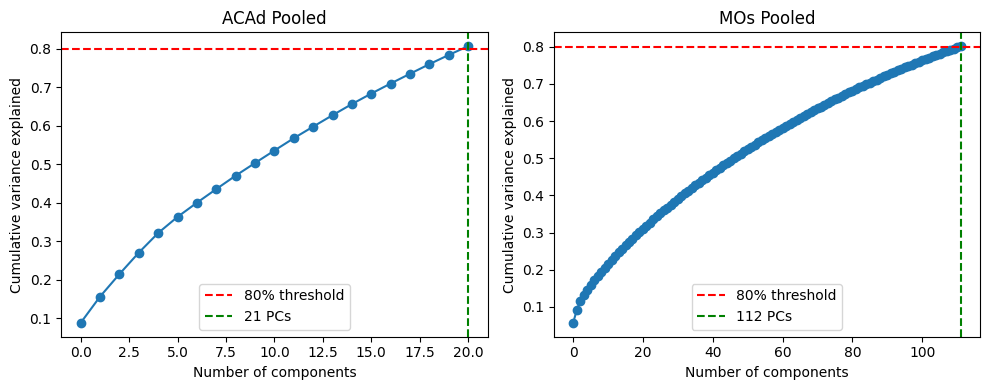

In [11]:
# Visualize variance explained (pooled PCA basis per area)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(A_cumvar[:A_npc], 'o-')
axes[0].axhline(0.8, color='r', linestyle='--', label='80% threshold')
axes[0].axvline(A_npc - 1, color='g', linestyle='--', label=f'{A_npc} PCs')
axes[0].set_title(f'{struct1} Pooled')
axes[0].set_xlabel('Number of components')
axes[0].set_ylabel('Cumulative variance explained')
axes[0].legend()

axes[1].plot(B_cumvar[:B_npc], 'o-')
axes[1].axhline(0.8, color='r', linestyle='--', label='80% threshold')
axes[1].axvline(B_npc - 1, color='g', linestyle='--', label=f'{B_npc} PCs')
axes[1].set_title(f'{struct2} Pooled')
axes[1].set_xlabel('Number of components')
axes[1].set_ylabel('Cumulative variance explained')
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Perform CCA Between Brain Areas

In [12]:
def run_cca(X1, X2, n_components=None):
    """Run CCA between two datasets."""
    d = min(X1.shape[1], X2.shape[1])
    if n_components is None:
        n_components = d
    n_components = min(n_components, d, X1.shape[0] - 1, X2.shape[0] - 1)
    if n_components < 1:
        raise ValueError("Not enough samples to fit CCA.")
    cca = CCA(n_components=n_components)
    cca.fit(X1, X2)
    X1_c, X2_c = cca.transform(X1, X2)
    return cca, X1_c, X2_c

print("CCA function defined")

CCA function defined


In [13]:
# Match dimensions between areas
A_task_pca_m, B_task_pca_m, d_task = match_dims(A_task_pca, B_task_pca)
A_spont_pca_m, B_spont_pca_m, d_spont = match_dims(A_spont_pca, B_spont_pca)

print(f"Matched dimensions - Task: {d_task}, Spontaneous: {d_spont}")

# Choose number of CCA components (e.g., 5 or all available)
k_task = min(10, d_task)
k_spont = min(10, d_spont)

print(f"CCA components - Task: {k_task}, Spontaneous: {k_spont}")

Matched dimensions - Task: 21, Spontaneous: 21
CCA components - Task: 10, Spontaneous: 10


In [14]:
# Run CCA for task and spontaneous epochs
cca_task, A_task_c, B_task_c = run_cca(A_task_pca_m, B_task_pca_m, n_components=k_task)
cca_spont, A_spont_c, B_spont_c = run_cca(A_spont_pca_m, B_spont_pca_m, n_components=k_spont)

print(f"CCA completed")
print(f"  Task canonical variables shape: {A_task_c.shape}")
print(f"  Spontaneous canonical variables shape: {A_spont_c.shape}")

CCA completed
  Task canonical variables shape: (538, 10)
  Spontaneous canonical variables shape: (94, 10)


## 6. Calculate Canonical Correlations

In [15]:
# Calculate canonical correlations
corrs_task = canonical_corrs(A_task_c, B_task_c)
corrs_spont = canonical_corrs(A_spont_c, B_spont_c)

print(f"\nCanonical correlations:")
print(f"  Task: {corrs_task}")
print(f"  Spontaneous: {corrs_spont}")

# Basic comparison
print(f"\nMean correlation:")
print(f"  Task: {np.mean(corrs_task):.3f}")
print(f"  Spontaneous: {np.mean(corrs_spont):.3f}")
print(f"  Difference: {np.mean(corrs_task) - np.mean(corrs_spont):.3f}")


Canonical correlations:
  Task: [0.80718038 0.77363959 0.62555041 0.60653032 0.45151122 0.38461044
 0.33877492 0.2982263  0.27694866 0.26473389]
  Spontaneous: [0.91529419 0.83452909 0.78536817 0.76544772 0.70036849 0.66521608
 0.63898826 0.60084234 0.52149086 0.51315878]

Mean correlation:
  Task: 0.483
  Spontaneous: 0.694
  Difference: -0.211


In [16]:
# transform task data into spontaneous CCA space
A_task_c_in_spont, B_task_c_in_spont = cca_spont.transform(A_task_pca_m,B_task_pca_m)
corrs_task_in_spont = canonical_corrs(A_task_c_in_spont, B_task_c_in_spont)

print(f"\nCanonical correlations for task data projected into spontaneous CCA space:")
print(f"  Task in Spont CCA space: {corrs_task_in_spont}")


#transform spontaneous data into task CCA space
A_spont_c_in_task, B_spont_c_in_task = cca_task.transform(A_spont_pca_m, B_spont_pca_m)
corrs_spont_in_task = canonical_corrs(A_spont_c_in_task, B_spont_c_in_task)

print(f"\nCanonical correlations for spontaneous data projected into task CCA space:")
print(f"  Spont in Task CCA space: {corrs_spont_in_task}")

# mean correlations:
print(f"\nMean correlations in cross-projected spaces:")
print(f"  Task in Spont CCA space: {np.mean(corrs_task_in_spont):.3f}")
print(f"  Spont in Task CCA space: {np.mean(corrs_spont_in_task):.3f}")


Canonical correlations for task data projected into spontaneous CCA space:
  Task in Spont CCA space: [ 0.47219564  0.15903575  0.07736248  0.15259941  0.04087108 -0.08300321
  0.31223106 -0.0169926  -0.09933292  0.35602282]

Canonical correlations for spontaneous data projected into task CCA space:
  Spont in Task CCA space: [ 0.54131934  0.52172079 -0.13197589  0.26462519 -0.26733905  0.04483761
 -0.13572915 -0.07433913  0.18161387 -0.28026823]

Mean correlations in cross-projected spaces:
  Task in Spont CCA space: 0.137
  Spont in Task CCA space: 0.066


## 7. Bootstrap Significance Testing

In [27]:
def bootstrap_corrs(X, Y, n_components, n_boot=1000):
    """Bootstrap canonical correlations within an epoch."""
    n_samples = X.shape[0]
    boot_corrs = np.zeros((n_boot, n_components))
    for b in range(n_boot):
        idx = np.random.choice(n_samples, n_samples, replace=True)
        cca, X_c, Y_c = run_cca(X[idx], Y[idx], n_components=n_components)
        boot_corrs[b] = canonical_corrs(X_c, Y_c)
    return boot_corrs

print("Bootstrap function defined")

Bootstrap function defined


In [ ]:
# Run bootstrap for task and spontaneous (reduced iterations for speed)
n_boot = 10
print(f"Running bootstrap with {n_boot} iterations...")

boot_task = bootstrap_corrs(A_task_pca_m, B_task_pca_m, k_task, n_boot=n_boot)
boot_spont = bootstrap_corrs(A_spont_pca_m, B_spont_pca_m, k_spont, n_boot=n_boot)

# Calculate confidence intervals
task_ci = np.percentile(boot_task, [2.5, 97.5], axis=0)
spont_ci = np.percentile(boot_spont, [2.5, 97.5], axis=0)

print(f"\nBootstrap completed")
print(f"Task 95% CI for component 1: [{task_ci[0, 0]:.3f}, {task_ci[1, 0]:.3f}]")
print(f"Spontaneous 95% CI for component 1: [{spont_ci[0, 0]:.3f}, {spont_ci[1, 0]:.3f}]")

Running bootstrap with 500 iterations...


c:\Anaconda3\envs\dr_ibl_analysis\Lib\site-packages\sklearn\cross_decomposition\_pls.py:113: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)
c:\Anaconda3\envs\dr_ibl_analysis\Lib\site-packages\sklearn\cross_decomposition\_pls.py:113: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)
c:\Anaconda3\envs\dr_ibl_analysis\Lib\site-packages\sklearn\cross_decomposition\_pls.py:113: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)
c:\Anaconda3\envs\dr_ibl_analysis\Lib\site-packages\sklearn\cross_decomposition\_pls.py:113: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)
c:\Anaconda3\envs\dr_ibl_analysis\Lib\site-packages\sklearn\cross_decomposition\_pls.py:113: Con


Bootstrap completed
Task 95% CI for component 1: [0.917, 0.938]
Spontaneous 95% CI for component 1: [0.983, 1.000]


In [28]:
# Test for significant difference between task and spontaneous
def bootstrap_diff(X1_task, Y1_task, X1_spont, Y1_spont, n_components, n_boot=1000):
    """Bootstrap the difference in canonical correlations between epochs."""
    n_task = X1_task.shape[0]
    n_spont = X1_spont.shape[0]
    diff_boot = np.zeros((n_boot, n_components))
    
    for b in range(n_boot):
        idx_task = np.random.choice(n_task, n_task, replace=True)
        idx_spont = np.random.choice(n_spont, n_spont, replace=True)
        
        _, X_task_c, Y_task_c = run_cca(X1_task[idx_task], Y1_task[idx_task], n_components)
        _, X_spont_c, Y_spont_c = run_cca(X1_spont[idx_spont], Y1_spont[idx_spont], n_components)
        
        r_task = canonical_corrs(X_task_c, Y_task_c)
        r_spont = canonical_corrs(X_spont_c, Y_spont_c)
        
        diff_boot[b] = r_task - r_spont
    
    return diff_boot

print("Bootstrap difference function defined")

Bootstrap difference function defined


In [20]:
# Run bootstrap for differences
k_min = min(k_task, k_spont)
print(f"Running bootstrap for differences with {n_boot} iterations...")

diff_boot = bootstrap_diff(
    A_task_pca_m, B_task_pca_m,
    A_spont_pca_m, B_spont_pca_m,
    n_components=k_min,
    n_boot=n_boot
)

diff_ci = np.percentile(diff_boot, [2.5, 97.5], axis=0)
diff_mean = np.mean(diff_boot, axis=0)

print(f"\nDifference in canonical correlations (Task - Spontaneous):")
for i in range(k_min):
    significant = "***" if (diff_ci[0, i] > 0 or diff_ci[1, i] < 0) else "n.s."
    print(f"  Component {i+1}: {diff_mean[i]:.3f} [{diff_ci[0, i]:.3f}, {diff_ci[1, i]:.3f}] {significant}")

Running bootstrap for differences with 500 iterations...


c:\Anaconda3\envs\dr_ibl_analysis\Lib\site-packages\sklearn\cross_decomposition\_pls.py:113: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)
c:\Anaconda3\envs\dr_ibl_analysis\Lib\site-packages\sklearn\cross_decomposition\_pls.py:113: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)
c:\Anaconda3\envs\dr_ibl_analysis\Lib\site-packages\sklearn\cross_decomposition\_pls.py:113: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)
c:\Anaconda3\envs\dr_ibl_analysis\Lib\site-packages\sklearn\cross_decomposition\_pls.py:113: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)
c:\Anaconda3\envs\dr_ibl_analysis\Lib\site-packages\sklearn\cross_decomposition\_pls.py:113: Con


Difference in canonical correlations (Task - Spontaneous):
  Component 1: -0.065 [-0.078, -0.051] ***
  Component 2: -0.088 [-0.107, -0.066] ***
  Component 3: -0.125 [-0.154, -0.095] ***
  Component 4: -0.176 [-0.216, -0.140] ***
  Component 5: -0.232 [-0.282, -0.181] ***
  Component 6: -0.270 [-0.318, -0.217] ***
  Component 7: -0.297 [-0.353, -0.235] ***
  Component 8: -0.330 [-0.388, -0.264] ***
  Component 9: -0.349 [-0.414, -0.273] ***
  Component 10: -0.363 [-0.424, -0.292] ***


## 8. Compare Communication Subspaces Across Epochs

In [17]:
def principal_angles(U, V):
    """
    Calculate principal angles between two subspaces.
    U, V: (d × k) matrices.
    Returns principal angles in radians.
    """
    Uo, _ = np.linalg.qr(U)
    Vo, _ = np.linalg.qr(V)
    s = np.linalg.svd(Uo.T @ Vo, compute_uv=False)
    s = np.clip(s, -1.0, 1.0)
    return np.arccos(s)

print("Principal angles function defined")

Principal angles function defined


In [18]:
# Compare subspaces for area A (struct1)
k = min(k_task, k_spont)
subspace_compare_mode = "pooled_pca"  # "pooled_pca" or "neuron_space"

if subspace_compare_mode == "pooled_pca":
    U_task_A = cca_task.x_weights_[:, :k]
    U_spont_A = cca_spont.x_weights_[:, :k]
    U_task_B = cca_task.y_weights_[:, :k]
    U_spont_B = cca_spont.y_weights_[:, :k]
elif subspace_compare_mode == "neuron_space":
    U_task_A = pca_A.components_.T @ cca_task.x_weights_[:, :k]
    U_spont_A = pca_A.components_.T @ cca_spont.x_weights_[:, :k]
    U_task_B = pca_B.components_.T @ cca_task.y_weights_[:, :k]
    U_spont_B = pca_B.components_.T @ cca_spont.y_weights_[:, :k]
else:
    raise ValueError("subspace_compare_mode must be 'pooled_pca' or 'neuron_space'.")

angles_A = principal_angles(U_task_A, U_spont_A)
angles_A_deg = angles_A * 180 / np.pi

print(f"\nPrincipal angles for {struct1} (degrees):")
print(angles_A_deg)
print(f"Mean angle: {np.mean(angles_A_deg):.2f}°")

angles_B = principal_angles(U_task_B, U_spont_B)
angles_B_deg = angles_B * 180 / np.pi

print(f"\nPrincipal angles for {struct2} (degrees):")
print(angles_B_deg)
print(f"Mean angle: {np.mean(angles_B_deg):.2f}°")


Principal angles for ACAd (degrees):
[ 2.03286675  4.54145408 15.89602364 23.68886963 28.54244788 43.16996518
 52.10395029 59.03846183 79.46468833 84.55777582]
Mean angle: 39.30°

Principal angles for MOs (degrees):
[ 7.76783325 11.81983284 20.27457185 24.62191145 36.31272635 44.63585028
 51.25983727 72.99804577 80.79136594 82.99133692]
Mean angle: 43.35°


## 9. Visualize Canonical Correlations

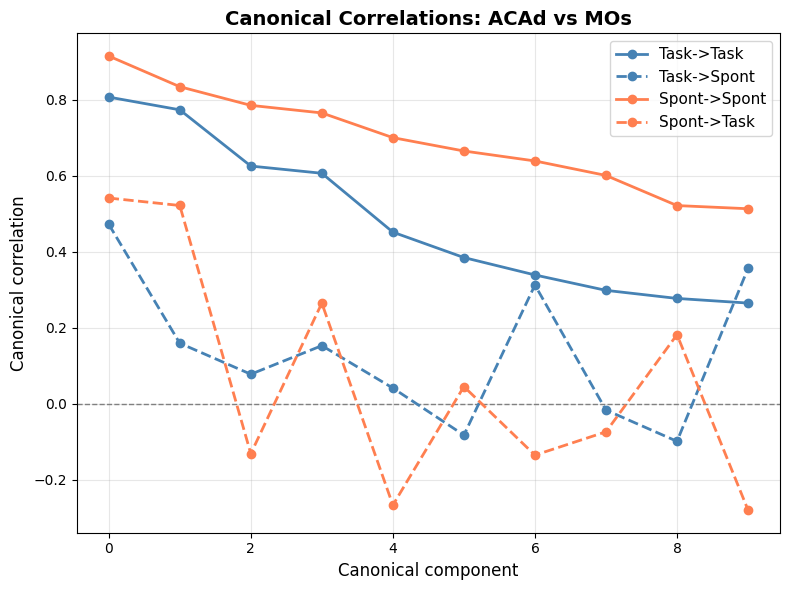

In [19]:
# Plot canonical correlations with bootstrap confidence intervals
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

x_task = np.arange(len(corrs_task))
x_spont = np.arange(len(corrs_spont))

ax.axhline(0, color='gray', linestyle='--', linewidth=1)

# Plot task
ax.errorbar(
    x_task, corrs_task,
    # yerr=np.abs([task_ci[0]-corrs_task, task_ci[1]-corrs_task]),
    fmt='o-', linewidth=2, capsize=5, capthick=2,
    label='Task->Task', color='steelblue'
)

ax.errorbar(
    x_task, corrs_task_in_spont,
    # yerr=np.abs([task_ci[0]-corrs_task_in_spont, task_ci[1]-corrs_task_in_spont]),
    fmt='o--', linewidth=2, capsize=5, capthick=2,
    label='Task->Spont', color='steelblue'
)

# Plot spontaneous
ax.errorbar(
    x_spont, corrs_spont,
    # yerr=[spont_ci[0]-corrs_spont, spont_ci[1]-corrs_spont],
    fmt='o-', linewidth=2, capsize=5, capthick=2,
    label='Spont->Spont', color='coral'
)

ax.errorbar(
    x_spont, corrs_spont_in_task,
    # yerr=[spont_ci[0]-corrs_spont_in_task, spont_ci[1]-corrs_spont_in_task],
    fmt='o--', linewidth=2, capsize=5, capthick=2,
    label='Spont->Task', color='coral'
)

ax.set_xlabel('Canonical component', fontsize=12)
ax.set_ylabel('Canonical correlation', fontsize=12)
ax.set_title(f'Canonical Correlations: {struct1} vs {struct2}', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
# ax.set_ylim([0, 1])

plt.tight_layout()
plt.show()

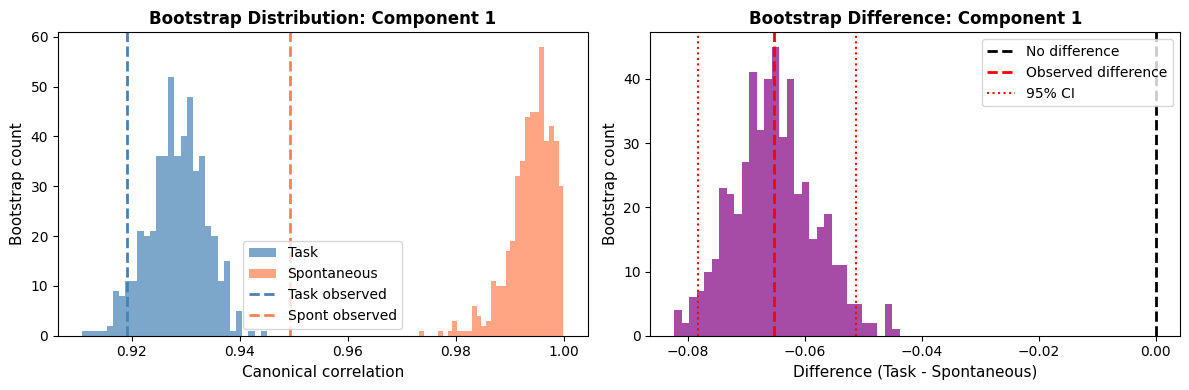

In [24]:
# Plot bootstrap distributions for first canonical component
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(boot_task[:, 0], bins=30, alpha=0.7, color='steelblue', label='Task')
axes[0].hist(boot_spont[:, 0], bins=30, alpha=0.7, color='coral', label='Spontaneous')
axes[0].axvline(corrs_task[0], color='steelblue', linestyle='--', linewidth=2, label='Task observed')
axes[0].axvline(corrs_spont[0], color='coral', linestyle='--', linewidth=2, label='Spont observed')
axes[0].set_xlabel('Canonical correlation', fontsize=11)
axes[0].set_ylabel('Bootstrap count', fontsize=11)
axes[0].set_title('Bootstrap Distribution: Component 1', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)

# Plot difference distribution
axes[1].hist(diff_boot[:, 0], bins=30, alpha=0.7, color='purple')
axes[1].axvline(0, color='black', linestyle='--', linewidth=2, label='No difference')
axes[1].axvline(diff_mean[0], color='red', linestyle='--', linewidth=2, label='Observed difference')
axes[1].axvline(diff_ci[0, 0], color='red', linestyle=':', linewidth=1.5, label='95% CI')
axes[1].axvline(diff_ci[1, 0], color='red', linestyle=':', linewidth=1.5)
axes[1].set_xlabel('Difference (Task - Spontaneous)', fontsize=11)
axes[1].set_ylabel('Bootstrap count', fontsize=11)
axes[1].set_title('Bootstrap Difference: Component 1', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

## 10. Visualize Subspace Angles

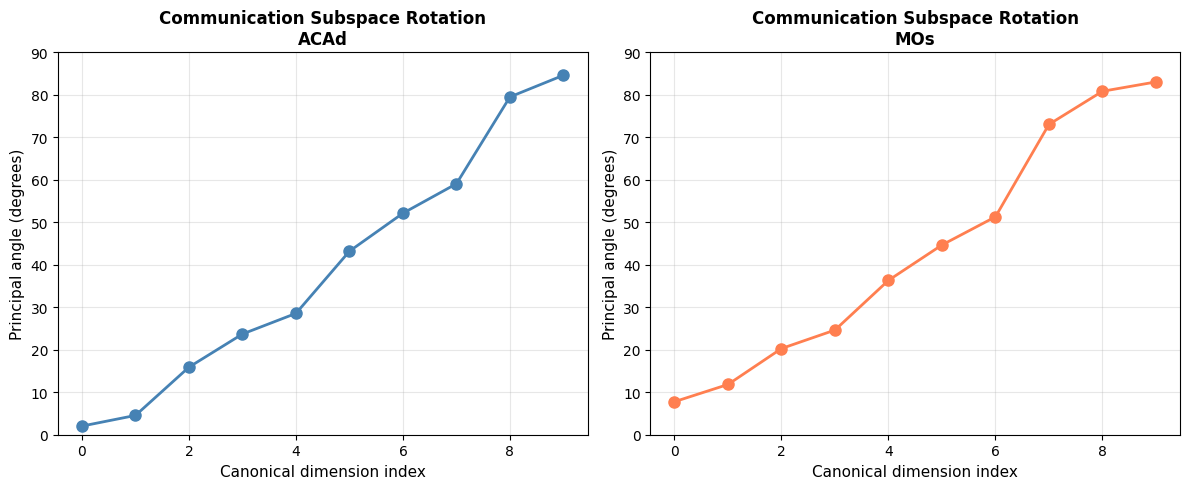


Interpretation:
  Small angles (< 30°): Subspaces are very similar between task and spontaneous
  Medium angles (30-60°): Moderate rotation of subspaces
  Large angles (> 60°): Substantial reorganization of communication subspace


In [20]:
# Plot principal angles
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(angles_A_deg, 'o-', linewidth=2, markersize=8, color='steelblue')
axes[0].set_xlabel('Canonical dimension index', fontsize=11)
axes[0].set_ylabel('Principal angle (degrees)', fontsize=11)
axes[0].set_title(f'Communication Subspace Rotation\n{struct1}', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)
axes[0].set_ylim([0, 90])

axes[1].plot(angles_B_deg, 'o-', linewidth=2, markersize=8, color='coral')
axes[1].set_xlabel('Canonical dimension index', fontsize=11)
axes[1].set_ylabel('Principal angle (degrees)', fontsize=11)
axes[1].set_title(f'Communication Subspace Rotation\n{struct2}', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)
axes[1].set_ylim([0, 90])

plt.tight_layout()
plt.show()

print(f"\nInterpretation:")
print(f"  Small angles (< 30°): Subspaces are very similar between task and spontaneous")
print(f"  Medium angles (30-60°): Moderate rotation of subspaces")
print(f"  Large angles (> 60°): Substantial reorganization of communication subspace")

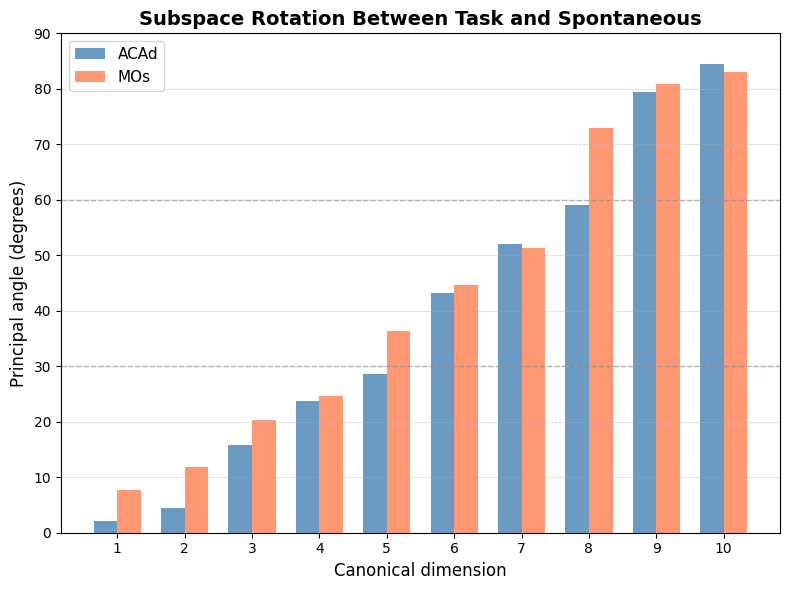

In [21]:
# Combined visualization of angles
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

x = np.arange(len(angles_A_deg))
width = 0.35

bars1 = ax.bar(x - width/2, angles_A_deg, width, label=struct1, color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, angles_B_deg, width, label=struct2, color='coral', alpha=0.8)

ax.set_xlabel('Canonical dimension', fontsize=12)
ax.set_ylabel('Principal angle (degrees)', fontsize=12)
ax.set_title('Subspace Rotation Between Task and Spontaneous', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'{i+1}' for i in x])
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 90])

# Add reference lines
ax.axhline(30, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.axhline(60, color='gray', linestyle='--', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.show()

## 11. Plot Canonical Variable Trajectories

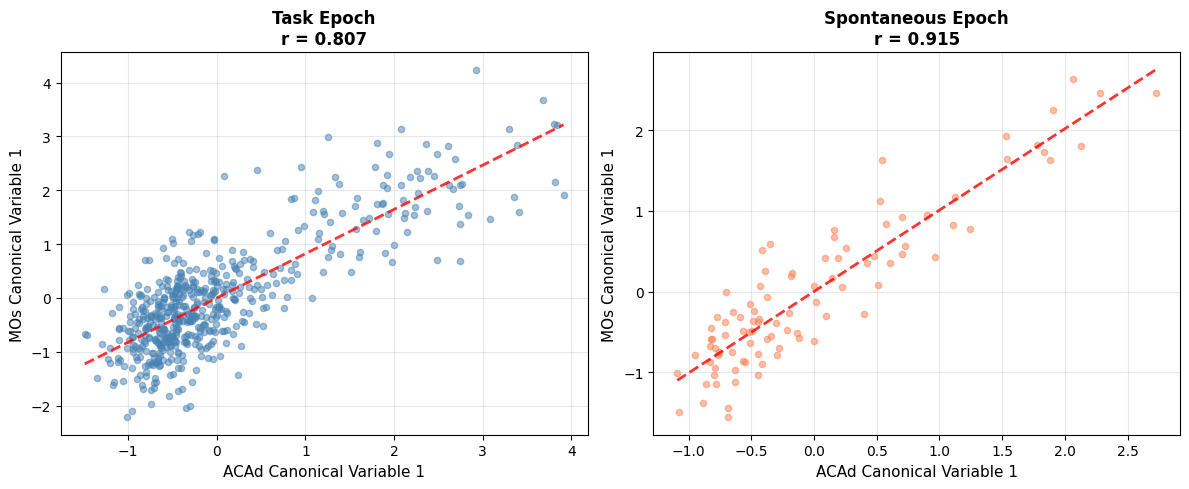

In [22]:
# Plot relationship between canonical variables for first component
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Task
axes[0].scatter(A_task_c[:, 0], B_task_c[:, 0], alpha=0.5, s=20, color='steelblue')
axes[0].set_xlabel(f'{struct1} Canonical Variable 1', fontsize=11)
axes[0].set_ylabel(f'{struct2} Canonical Variable 1', fontsize=11)
axes[0].set_title(f'Task Epoch\nr = {corrs_task[0]:.3f}', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)

# Add regression line
z = np.polyfit(A_task_c[:, 0], B_task_c[:, 0], 1)
p = np.poly1d(z)
x_line = np.linspace(A_task_c[:, 0].min(), A_task_c[:, 0].max(), 100)
axes[0].plot(x_line, p(x_line), "r--", linewidth=2, alpha=0.8)

# Spontaneous
axes[1].scatter(A_spont_c[:, 0], B_spont_c[:, 0], alpha=0.5, s=20, color='coral')
axes[1].set_xlabel(f'{struct1} Canonical Variable 1', fontsize=11)
axes[1].set_ylabel(f'{struct2} Canonical Variable 1', fontsize=11)
axes[1].set_title(f'Spontaneous Epoch\nr = {corrs_spont[0]:.3f}', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)

# Add regression line
z = np.polyfit(A_spont_c[:, 0], B_spont_c[:, 0], 1)
p = np.poly1d(z)
x_line = np.linspace(A_spont_c[:, 0].min(), A_spont_c[:, 0].max(), 100)
axes[1].plot(x_line, p(x_line), "r--", linewidth=2, alpha=0.8)

plt.tight_layout()
plt.show()

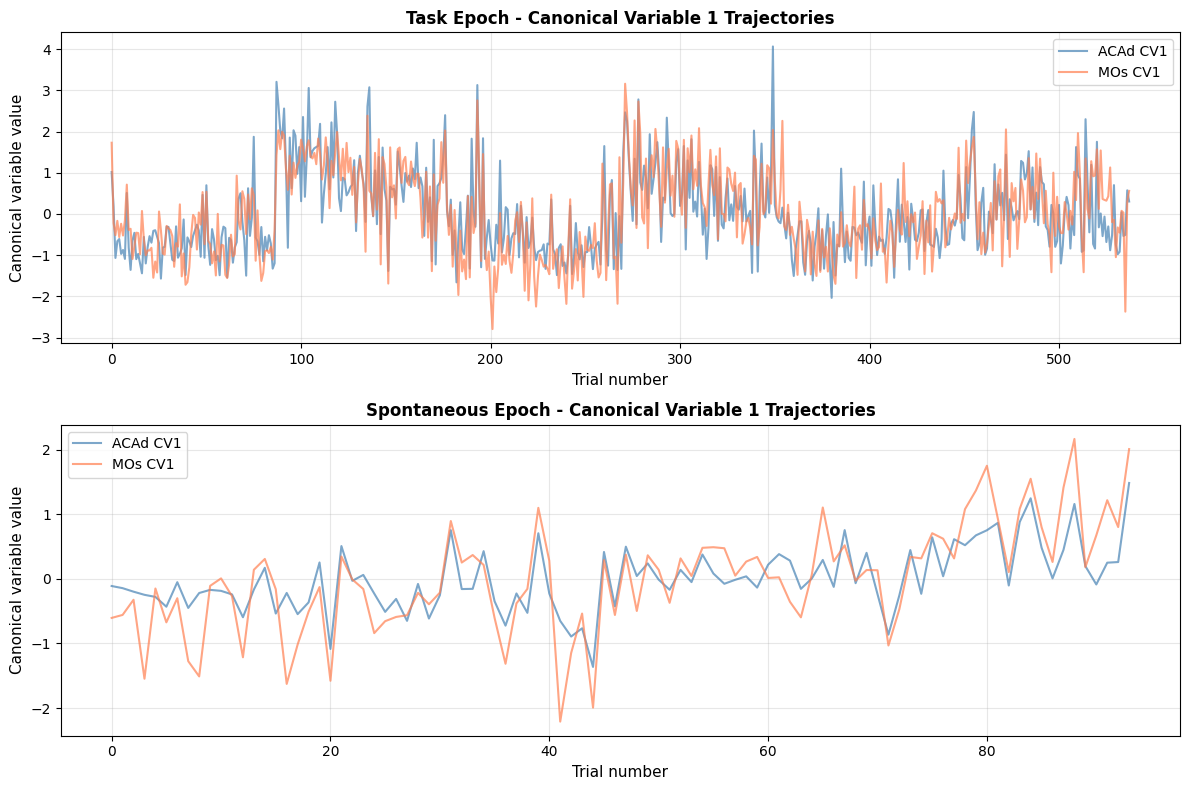

In [26]:
# Plot time series of canonical variables (first component)
plot_component=1

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Task
axes[0].plot(A_task_c[:, plot_component], label=f'{struct1} CV{plot_component}', linewidth=1.5, alpha=0.7, color='steelblue')
axes[0].plot(B_task_c[:, plot_component], label=f'{struct2} CV{plot_component}', linewidth=1.5, alpha=0.7, color='coral')
axes[0].set_xlabel('Trial number', fontsize=11)
axes[0].set_ylabel('Canonical variable value', fontsize=11)
axes[0].set_title(f'Task Epoch - Canonical Variable {plot_component} Trajectories', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Spontaneous
axes[1].plot(A_spont_c[:, plot_component], label=f'{struct1} CV{plot_component}', linewidth=1.5, alpha=0.7, color='steelblue')
axes[1].plot(B_spont_c[:, plot_component], label=f'{struct2} CV{plot_component}', linewidth=1.5, alpha=0.7, color='coral')
axes[1].set_xlabel('Trial number', fontsize=11)
axes[1].set_ylabel('Canonical variable value', fontsize=11)
axes[1].set_title(f'Spontaneous Epoch - Canonical Variable {plot_component} Trajectories', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Summary

This analysis applies CCA to assess neural coupling between brain areas across task and spontaneous epochs:

1. **PCA preprocessing**: Reduced dimensionality while retaining 80% variance for each area/epoch
2. **CCA**: Identified maximally correlated dimensions between paired brain areas
3. **Bootstrap testing**: Quantified statistical significance of correlations and differences
4. **Subspace comparison**: Measured rotation of communication subspaces via principal angles
5. **Visualization**: Comprehensive plots showing correlation strength, confidence intervals, and trajectories

**Key findings:**
- Canonical correlations quantify trial-by-trial coupling between areas
- Bootstrap CI indicates reliability of estimated correlations
- Principal angles reveal whether the neural subspace mediating communication changes between epochs
- Small angles suggest persistent communication structure; large angles indicate reorganization

**Cross-session batch processing and aggregation**: See `CCA_cross_session.ipynb`.

In [29]:
# Optional: Save results for further analysis
results = {
    'structures': [struct1, struct2],
    'canonical_correlations': {
        'task': corrs_task,
        'spontaneous': corrs_spont,
        'difference': corrs_task[:k_min] - corrs_spont[:k_min]
    },
    'bootstrap': {
        'task_ci': task_ci,
        'spont_ci': spont_ci,
        'diff_ci': diff_ci,
        'diff_mean': diff_mean
    },
    'principal_angles': {
        struct1: angles_A_deg,
        struct2: angles_B_deg
    },
    'n_components': {
        'task': k_task,
        'spontaneous': k_spont
    }
}

print("\nAnalysis complete! Results dictionary contains:")
for key in results.keys():
    print(f"  - {key}")


Analysis complete! Results dictionary contains:
  - structures
  - canonical_correlations
  - bootstrap
  - principal_angles
  - n_components


## 12. All-Pairs CCA Analysis (Per Time Window)

Run the full CCA pipeline for every pair of brain areas, **separately for each time window**:

| Window | Period | Trials | Purpose |
|--------|--------|--------|---------|
| prestim | −0.5–0 s | all task | Baseline task communication |
| context | −0.2–0 s | all task | Pre-stimulus context coding |
| stim_vis | 0–0.1 s | visual stim only | Visual stimulus coupling |
| stim_aud | 0–0.1 s | auditory stim only | Auditory stimulus coupling |
| response | 0.3–0.5 s | all task | Motor/decision coupling |
| spontaneous | pre-task | spontaneous | Spontaneous baseline |

Stimulus windows are **split by modality** so CCA captures modality-specific
inter-area coupling rather than blending visual and auditory response patterns.

PCA bases are fit **once per structure** on data pooled across **all** windows.
CCA is then fit per (pair × window), yielding canonical correlations specific to each epoch.

**To skip recomputation**, set `LOAD_CACHED_CCA = True` below.

In [27]:
import pathlib
from itertools import combinations

# ── Configuration ──────────────────────────────────────────────────────────────
MIN_UNITS      = 5      # minimum units required in a structure to include it
VAR_THRESH     = 0.80   # PCA variance threshold
MAX_CCA_COMPS  = 10     # cap on number of CCA components per pair
N_BOOT         = 0      # bootstrap iterations (set to 0 to skip bootstrapping)

output_dir = pathlib.Path('../results/cca')
output_dir.mkdir(parents=True, exist_ok=True)

LOAD_CACHED_CCA = False  # Set True to load saved results instead of recomputing

# ── Identify qualifying structures ─────────────────────────────────────────────
unit_counts = units_filtered.groupby('structure')['unit_id'].nunique()
qualified_structures = sorted(unit_counts[unit_counts >= MIN_UNITS].index.tolist())

print(f"Structures with >= {MIN_UNITS} units: {len(qualified_structures)}")
print(qualified_structures)
n_pairs = len(qualified_structures) * (len(qualified_structures) - 1) // 2
print(f"Total pairs to analyse: {n_pairs}")
print(f"\nLOAD_CACHED_CCA = {LOAD_CACHED_CCA}")

Structures with >= 5 units: 18
['ACAd', 'ACAv', 'CA1', 'CP', 'FRP', 'GU', 'ILA', 'LSr', 'MOs', 'OLF', 'ORBl', 'ORBm', 'ORBvl', 'PL', 'SSp', 'SSs', 'TTd', 'VISal']
Total pairs to analyse: 153

LOAD_CACHED_CCA = False


In [28]:
# ── Build trial tensors for all time windows ───────────────────────────────────
# These are needed BEFORE PCA so that PCA captures variance from all epochs.
#
# Pre-stimulus (0.5 s bin):  already built as trial_da  (cell 6)
# Spontaneous:               already built as spont_trial_da  (cell 8)
# Context window  (−0.2–0 s):
# Stimulus window (0–0.1 s):
# Response window (0.3–0.5 s):

print("Building context-window tensor (−0.2–0 s) ...")
trial_da_ctx = spike_utils.make_neuron_time_trials_tensor(
    units_filtered, trials,
    time_before=0.2, time_after=0.001, bin_size=0.2
)
print(f"  shape: {trial_da_ctx.shape},  time coords: {trial_da_ctx.time.values}")

print("Building stimulus-window tensor (0–0.1 s) ...")
trial_da_stim = spike_utils.make_neuron_time_trials_tensor(
    units_filtered, trials,
    time_before=0, time_after=0.101, bin_size=0.1
)
print(f"  shape: {trial_da_stim.shape},  time coords: {trial_da_stim.time.values}")

print("Building response-window tensor (0.3–0.5 s) ...")
trial_da_resp = spike_utils.make_neuron_time_trials_tensor(
    units_filtered, trials,
    time_before=-0.3, time_after=0.501, bin_size=0.2
)
print(f"  shape: {trial_da_resp.shape},  time coords: {trial_da_resp.time.values}")

Building context-window tensor (−0.2–0 s) ...
  shape: (1097, 1, 538),  time coords: [-0.1]
Building stimulus-window tensor (0–0.1 s) ...
  shape: (1097, 1, 538),  time coords: [0.05]
Building response-window tensor (0.3–0.5 s) ...
  shape: (1097, 1, 538),  time coords: [0.4]


In [29]:
# ── Pre-compute data arrays and pooled PCA for each qualifying structure ────────
# PCA is fit on ALL time windows (pre-stim, context, stimulus, response, spontaneous)
# so that the basis captures variance from every epoch analysed in this notebook.
# A single StandardScaler is also fit on all pooled data per structure.

struct_data = {}
time_idx = 0  # single time-bin per tensor

for struct in qualified_structures:
    uid = units_filtered[units_filtered['structure'] == struct]['unit_id'].unique()

    # Raw (trials x neurons) matrices for each window
    A_prestim = trial_da.sel(unit_id=uid).data[:, time_idx, :].T        # pre-stim (-0.5-0 s)
    A_spont   = spont_trial_da.sel(unit_id=uid).data[:, time_idx, :].T  # spontaneous
    A_ctx     = trial_da_ctx.sel(unit_id=uid).data[:, time_idx, :].T    # context (-0.2-0 s)
    A_stim    = trial_da_stim.sel(unit_id=uid).data[:, time_idx, :].T   # stimulus (0-0.1 s)
    A_resp    = trial_da_resp.sel(unit_id=uid).data[:, time_idx, :].T   # response (0.3-0.5 s)

    # Pooled z-score across ALL windows
    A_all_raw = np.vstack([A_prestim, A_spont, A_ctx, A_stim, A_resp])
    scaler = StandardScaler().fit(A_all_raw)

    prestim_z = scaler.transform(A_prestim)
    spont_z   = scaler.transform(A_spont)
    ctx_z     = scaler.transform(A_ctx)
    stim_z    = scaler.transform(A_stim)
    resp_z    = scaler.transform(A_resp)

    # Fit PCA on ALL z-scored data
    A_all_z = np.vstack([prestim_z, spont_z, ctx_z, stim_z, resp_z])
    pca, n_pc, cumvar = pca_fit_keep(A_all_z, var_thresh=VAR_THRESH)

    struct_data[struct] = {
        'scaler'     : scaler,
        'pca'        : pca,
        'n_pc'       : n_pc,
        'n_units'    : len(uid),
        'task_z'     : prestim_z,
        'spont_z'    : spont_z,
        # CCA uses pre-stimulus projections
        'task_pca'   : pca.transform(prestim_z),
        'spont_pca'  : pca.transform(spont_z),
        # Coding axes use time-window-specific projections
        'context_pca': pca.transform(ctx_z),
        'stim_pca'   : pca.transform(stim_z),
        'resp_pca'   : pca.transform(resp_z),
    }

print("Per-structure PCA complete (fit on all time windows).")
for s, d in struct_data.items():
    print(f"  {s:15s}  units={d['n_units']:3d}  PCs={d['n_pc']:3d}  "
          f"task_pca={d['task_pca'].shape}  context={d['context_pca'].shape}  "
          f"stim={d['stim_pca'].shape}  resp={d['resp_pca'].shape}")

Per-structure PCA complete (fit on all time windows).
  ACAd             units= 33  PCs= 24  task_pca=(538, 24)  context=(538, 24)  stim=(538, 24)  resp=(538, 24)
  ACAv             units= 22  PCs= 16  task_pca=(538, 16)  context=(538, 16)  stim=(538, 16)  resp=(538, 16)
  CA1              units=  6  PCs=  5  task_pca=(538, 5)  context=(538, 5)  stim=(538, 5)  resp=(538, 5)
  CP               units= 42  PCs= 27  task_pca=(538, 27)  context=(538, 27)  stim=(538, 27)  resp=(538, 27)
  FRP              units=  6  PCs=  5  task_pca=(538, 5)  context=(538, 5)  stim=(538, 5)  resp=(538, 5)
  GU               units= 33  PCs= 25  task_pca=(538, 25)  context=(538, 25)  stim=(538, 25)  resp=(538, 25)
  ILA              units=100  PCs= 68  task_pca=(538, 68)  context=(538, 68)  stim=(538, 68)  resp=(538, 68)
  LSr              units= 27  PCs= 19  task_pca=(538, 19)  context=(538, 19)  stim=(538, 19)  resp=(538, 19)
  MOs              units=223  PCs=138  task_pca=(538, 138)  context=(538, 138)  st

In [30]:
from collections import OrderedDict

# ── Time windows for CCA ──────────────────────────────────────────────────────
# Each entry maps a window name to (pca_key, trial_mask_or_None).
# trial_mask is a boolean array over task trials; None means use all trials.
# Stimulus windows are split by modality so CCA captures modality-specific coupling.

vis_mask = trials['is_vis_stim'].values.astype(bool)
aud_mask = trials['is_aud_stim'].values.astype(bool)

CCA_WINDOWS = OrderedDict([
    ('prestim',     ('task_pca',    None)),
    ('context',     ('context_pca', None)),
    ('stim_vis',    ('stim_pca',    vis_mask)),
    ('stim_aud',    ('stim_pca',    aud_mask)),
    ('response',    ('resp_pca',    None)),
    ('spontaneous', ('spont_pca',   None)),
])


def run_cca_window(dA, dB, pca_key, trial_mask=None,
                   max_cca_comps=MAX_CCA_COMPS, n_boot=N_BOOT):
    """
    Run CCA between two areas for a single time window.

    Parameters
    ----------
    dA, dB : dict
        Per-structure data dicts from struct_data.
    pca_key : str
        Key into dA/dB for the PCA projections to use.
    trial_mask : array-like or None
        Boolean mask selecting which trials to use. None = all trials.
        For 'spont_pca' the mask is ignored (spontaneous has its own trial set).

    Returns
    -------
    list[dict]  — one record per canonical component.
    """
    A, B = dA[pca_key], dB[pca_key]

    if trial_mask is not None and pca_key != 'spont_pca':
        mask = np.asarray(trial_mask, dtype=bool)
        A, B = A[mask], B[mask]

    A_m, B_m, d = match_dims(A, B)
    k = min(max_cca_comps, d, A_m.shape[0] - 1, B_m.shape[0] - 1)
    if k < 1:
        return []

    try:
        cca, A_c, B_c = run_cca(A_m, B_m, n_components=k)
    except Exception:
        return []

    r = canonical_corrs(A_c, B_c)

    ci = np.full((2, k), np.nan)
    if n_boot > 0:
        boot = bootstrap_corrs(A_m, B_m, n_components=k, n_boot=n_boot)
        ci = np.percentile(boot, [2.5, 97.5], axis=0)

    records = []
    for i in range(k):
        records.append({
            'component'    : i + 1,
            'n_cca_comps'  : k,
            'r'            : r[i],
            'r_ci_lo'      : ci[0, i],
            'r_ci_hi'      : ci[1, i],
            'n_pca_A'      : dA['n_pc'],
            'n_pca_B'      : dB['n_pc'],
            'n_units_A'    : dA['n_units'],
            'n_units_B'    : dB['n_units'],
            'n_trials'     : A_m.shape[0],
        })
    return records


print(f"run_cca_window() defined.  Windows: {list(CCA_WINDOWS.keys())}")
print(f"  vis trials: {vis_mask.sum()},  aud trials: {aud_mask.sum()}")

run_cca_window() defined.  Windows: ['prestim', 'context', 'stim_vis', 'stim_aud', 'response', 'spontaneous']
  vis trials: 246,  aud trials: 249


In [39]:
# LOAD_CACHED_CCA and 'cca_results_df' in dir()

In [40]:
import time
LOAD_CACHED_CCA=False

component_path = output_dir / f'cca_components_{session_id}.parquet'
summary_path   = output_dir / f'cca_summary_{session_id}.parquet'

if LOAD_CACHED_CCA and component_path.exists() and summary_path.exists():
    cca_results_df = pd.read_parquet(component_path)
    summary_df     = pd.read_parquet(summary_path)
    if 'time_window' not in cca_results_df.columns:
        print("Cached results use old format (no per-window CCA). Re-computing...")
    else:
        print(f"Loading cached CCA results from {output_dir}")
        print(f"  cca_results_df: {cca_results_df.shape}")
        print(f"  summary_df:     {summary_df.shape}")

if not (LOAD_CACHED_CCA and 'cca_results_df' in dir() and 'time_window' in cca_results_df.columns):
    all_records = []
    pairs = list(combinations(qualified_structures, 2))
    n_windows = len(CCA_WINDOWS)

    print(f"Running CCA for {len(pairs)} pairs x {n_windows} windows = "
          f"{len(pairs) * n_windows} fits  (n_boot={N_BOOT})...")
    t0 = time.time()

    for idx, (sA, sB) in enumerate(pairs):
        for win_name, (pca_key, trial_mask) in CCA_WINDOWS.items():
            records = run_cca_window(
                struct_data[sA], struct_data[sB], pca_key, trial_mask=trial_mask
            )
            for rec in records:
                rec['struct_A'] = sA
                rec['struct_B'] = sB
                rec['time_window'] = win_name
            all_records.extend(records)

        if (idx + 1) % 10 == 0 or (idx + 1) == len(pairs):
            elapsed = time.time() - t0
            print(f"  {idx+1:3d}/{len(pairs)} pairs  ({elapsed:.0f}s)")

    print(f"\nDone.  {len(all_records)} records across {n_windows} time windows.")

Running CCA for 171 pairs x 6 windows = 1026 fits  (n_boot=0)...
   10/171 pairs  (3s)
   20/171 pairs  (8s)
   30/171 pairs  (10s)
   40/171 pairs  (11s)
   50/171 pairs  (11s)
   60/171 pairs  (11s)
   70/171 pairs  (15s)
   80/171 pairs  (25s)
   90/171 pairs  (26s)
  100/171 pairs  (30s)


c:\Anaconda3\envs\dr_ibl_analysis\Lib\site-packages\sklearn\cross_decomposition\_pls.py:113: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)
c:\Anaconda3\envs\dr_ibl_analysis\Lib\site-packages\sklearn\cross_decomposition\_pls.py:113: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)


  110/171 pairs  (56s)


c:\Anaconda3\envs\dr_ibl_analysis\Lib\site-packages\sklearn\cross_decomposition\_pls.py:113: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)
c:\Anaconda3\envs\dr_ibl_analysis\Lib\site-packages\sklearn\cross_decomposition\_pls.py:113: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)


  120/171 pairs  (70s)


...

  140/171 pairs  (97s)
  150/171 pairs  (105s)


c:\Anaconda3\envs\dr_ibl_analysis\Lib\site-packages\sklearn\cross_decomposition\_pls.py:113: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)
c:\Anaconda3\envs\dr_ibl_analysis\Lib\site-packages\sklearn\cross_decomposition\_pls.py:113: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)
c:\Anaconda3\envs\dr_ibl_analysis\Lib\site-packages\sklearn\cross_decomposition\_pls.py:113: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)


  160/171 pairs  (122s)


c:\Anaconda3\envs\dr_ibl_analysis\Lib\site-packages\sklearn\cross_decomposition\_pls.py:113: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)


  170/171 pairs  (131s)
  171/171 pairs  (131s)

Done.  8634 records across 6 time windows.


In [37]:
# all_records

In [35]:
# ── Build tidy results DataFrame ───────────────────────────────────────────────
# Rebuild from all_records whenever fresh computation was done (cell above).
# If loaded from cache, cca_results_df already exists and all_records won't be set.
if 'all_records' in dir():
    col_order = [
        'session_id',
        'struct_A', 'struct_B',
        'time_window',
        'n_units_A', 'n_units_B',
        'n_pca_A', 'n_pca_B',
        'n_trials',
        'n_cca_comps', 'component',
        'r', 'r_ci_lo', 'r_ci_hi',
    ]

    cca_results_df = (
        pd.DataFrame(all_records)
        .assign(session_id=session_id)
        [col_order]
        .sort_values(['struct_A', 'struct_B', 'time_window', 'component'])
        .reset_index(drop=True)
    )

print(f"Shape: {cca_results_df.shape}")
print(f"Windows: {cca_results_df['time_window'].unique().tolist()}")
print(f"\nMean canonical correlation by window:")
print(cca_results_df.groupby('time_window')['r'].mean().round(3).to_string())
print()
cca_results_df.head(15)

NameError: name 'cca_results_df' is not defined

In [43]:
# cca_results_df['time_window'].unique()
CCA_WINDOWS.keys()

odict_keys(['prestim', 'context', 'stim_vis', 'stim_aud', 'response', 'spontaneous'])

In [ ]:
# ── Pair-level summary table (mean across components, per window) ──────────────
# Always rebuild when cca_results_df has been (re)built above.
if 'all_records' in dir() or 'summary_df' not in dir():
    summary_df = (
        cca_results_df
        .groupby(['session_id', 'struct_A', 'struct_B', 'time_window',
                  'n_units_A', 'n_units_B', 'n_pca_A', 'n_pca_B',
                  'n_trials', 'n_cca_comps'], sort=False)
        .agg(
            mean_r   = ('r', 'mean'),
            r_comp1  = ('r', 'first'),
        )
        .sort_values('mean_r', ascending=False)
        .reset_index()
    )

print(f"Pair-level summary: {len(summary_df)} rows "
      f"({len(summary_df) // len(CCA_WINDOWS)} pairs x {len(CCA_WINDOWS)} windows)")
summary_df.head(20)

Pair-level summary: 1026 rows (171 pairs x 6 windows)


,session_id,struct_A,struct_B,time_window,n_units_A,n_units_B,n_pca_A,n_pca_B,n_trials,n_cca_comps,mean_r,r_comp1
0,742903_2024-10-22,ORBvl,SSp,spontaneous,179,249,107,140,93,10,1.000000,1.000000
1,742903_2024-10-22,MOs,SSp,spontaneous,302,249,161,140,93,10,1.000000,1.000000
2,742903_2024-10-22,MOs,ORBvl,spontaneous,302,179,161,107,93,10,1.000000,1.000000
3,742903_2024-10-22,ILA,ORBvl,spontaneous,131,179,83,107,93,10,1.000000,1.000000
4,742903_2024-10-22,ILA,MOs,spontaneous,131,302,83,161,93,10,1.000000,1.000000
5,742903_2024-10-22,ILA,SSs,spontaneous,131,97,83,58,93,10,0.996439,0.999996
6,742903_2024-10-22,MOs,SSs,spontaneous,302,97,161,58,93,10,0.996291,0.999997
7,742903_2024-10-22,SSp,SSs,spontaneous,249,97,140,58,93,10,0.995971,0.999998
8,742903_2024-10-22,MOs,SSp,stim_vis,302,249,161,140,246,10,0.991326,0.999989
9,742903_2024-10-22,MOs,SSp,stim_aud,302,249,161,140,249,10,0.990185,0.999986


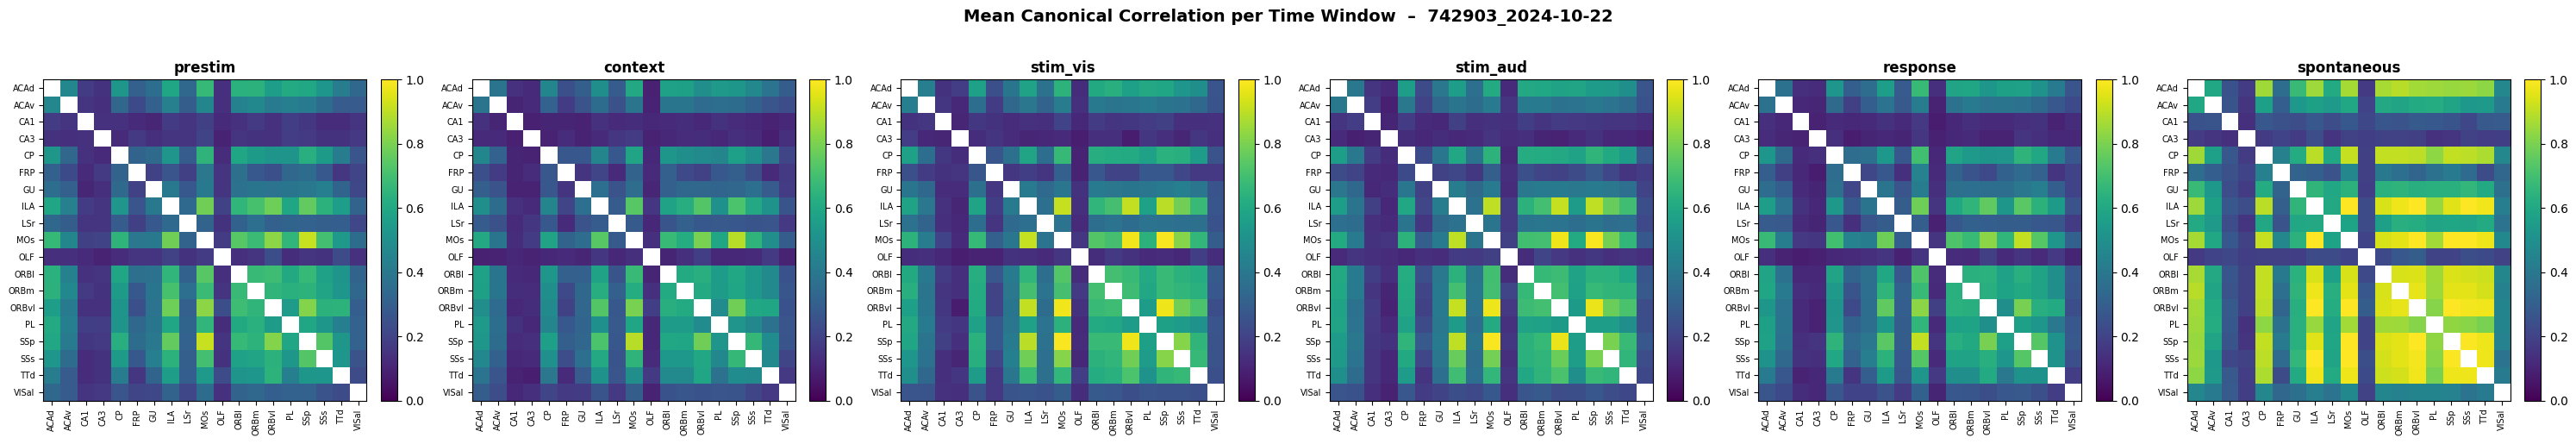

In [45]:
# ── Heatmaps: mean canonical correlation per time window ───────────────────────
def make_symmetric_matrix(df, value_col, structs):
    """Fill a symmetric N×N matrix from pairwise summary_df."""
    n = len(structs)
    idx = {s: i for i, s in enumerate(structs)}
    mat = np.full((n, n), np.nan)
    for _, row in df.iterrows():
        i, j = idx[row['struct_A']], idx[row['struct_B']]
        mat[i, j] = mat[j, i] = row[value_col]
    return mat

structs_sorted = sorted(qualified_structures)
window_names = list(CCA_WINDOWS.keys())
n_windows = len(window_names)

fig, axes = plt.subplots(1, n_windows, figsize=(5 * n_windows, 5))

for ax, win_name in zip(axes, window_names):
    sub = summary_df[summary_df['time_window'] == win_name]
    mat = make_symmetric_matrix(sub, 'mean_r', structs_sorted)
    im = ax.imshow(mat, vmin=0, vmax=1.0, cmap='viridis', aspect='auto')
    ax.set_xticks(range(len(structs_sorted)))
    ax.set_yticks(range(len(structs_sorted)))
    ax.set_xticklabels(structs_sorted, rotation=90, fontsize=7)
    ax.set_yticklabels(structs_sorted, fontsize=7)
    ax.set_title(win_name, fontsize=12, fontweight='bold')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle(f'Mean Canonical Correlation per Time Window  –  {session_id}',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [46]:
# ── Cross-window CCA subspace comparison ───────────────────────────────────────
# For each area pair, fit CCA per window, then measure subspace rotation via
# principal angles.  This quantifies how the "communication channel" changes
# across task phases.

cross_records = []

for sA, sB in combinations(qualified_structures, 2):
    dA, dB = struct_data[sA], struct_data[sB]

    # Fit CCA per window, store weights
    fits = {}
    for win_name, (pca_key, trial_mask) in CCA_WINDOWS.items():
        A, B = dA[pca_key], dB[pca_key]
        if trial_mask is not None and pca_key != 'spont_pca':
            mask = np.asarray(trial_mask, dtype=bool)
            A, B = A[mask], B[mask]
        A_m, B_m, d = match_dims(A, B)
        k = min(MAX_CCA_COMPS, d, A_m.shape[0] - 1, B_m.shape[0] - 1)
        if k < 1:
            continue
        try:
            cca_obj, _, _ = run_cca(A_m, B_m, n_components=k)
            fits[win_name] = (cca_obj, k, d)
        except Exception:
            continue

    # Compare all window pairs
    for (w1, (c1, k1, d1)), (w2, (c2, k2, d2)) in combinations(fits.items(), 2):
        k_min = min(k1, k2)
        d_min = min(d1, d2)
        if k_min < 1 or d_min < 1:
            continue

        angles_A = principal_angles(
            c1.x_weights_[:d_min, :k_min],
            c2.x_weights_[:d_min, :k_min]
        ) * 180 / np.pi

        angles_B = principal_angles(
            c1.y_weights_[:d_min, :k_min],
            c2.y_weights_[:d_min, :k_min]
        ) * 180 / np.pi

        cross_records.append({
            'struct_A': sA, 'struct_B': sB,
            'window_1': w1, 'window_2': w2,
            'mean_angle_A_deg': np.mean(angles_A),
            'mean_angle_B_deg': np.mean(angles_B),
            'mean_angle_deg': np.mean(np.concatenate([angles_A, angles_B])),
            'n_comps': k_min,
        })

cross_window_df = pd.DataFrame(cross_records)
print(f"Cross-window comparisons: {len(cross_window_df)}")
print(f"\nMean CCA subspace rotation between time windows (averaged over all pairs):")
print(
    cross_window_df.groupby(['window_1', 'window_2'])['mean_angle_deg']
    .agg(['mean', 'std']).round(1)
)

c:\Anaconda3\envs\dr_ibl_analysis\Lib\site-packages\sklearn\cross_decomposition\_pls.py:113: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)
c:\Anaconda3\envs\dr_ibl_analysis\Lib\site-packages\sklearn\cross_decomposition\_pls.py:113: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)
c:\Anaconda3\envs\dr_ibl_analysis\Lib\site-packages\sklearn\cross_decomposition\_pls.py:113: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)
c:\Anaconda3\envs\dr_ibl_analysis\Lib\site-packages\sklearn\cross_decomposition\_pls.py:113: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)
c:\Anaconda3\envs\dr_ibl_analysis\Lib\site-packages\sklearn\cross_decomposition\_pls.py:113: Con

Cross-window comparisons: 2565

Mean CCA subspace rotation between time windows (averaged over all pairs):
                      mean   std
window_1 window_2               
context  response     25.5  23.1
         spontaneous  28.5  26.1
         stim_aud     27.5  25.1
         stim_vis     27.3  24.9
prestim  context      19.1  17.5
         response     24.8  22.3
         spontaneous  28.3  26.0
         stim_aud     27.3  24.8
         stim_vis     27.0  24.6
response spontaneous  28.4  26.0
stim_aud response     27.6  25.2
         spontaneous  29.3  26.9
stim_vis response     27.5  25.1
         spontaneous  29.3  26.8
         stim_aud     28.4  26.0


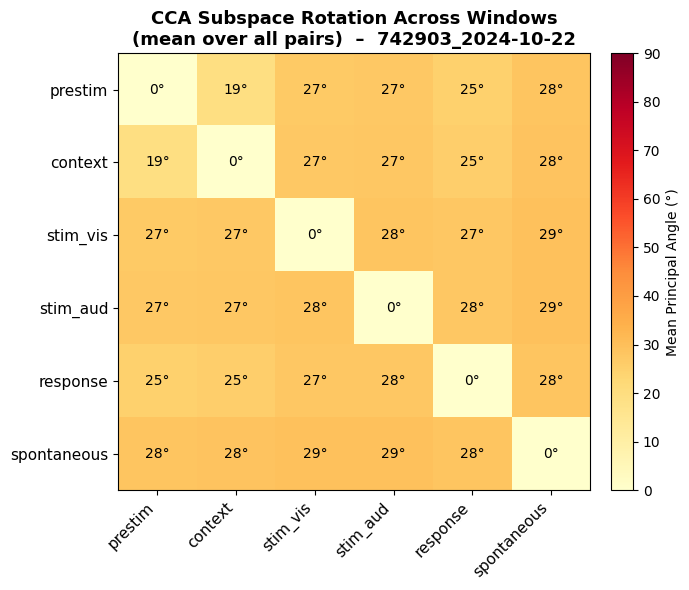

In [47]:
# ── Heatmap: CCA subspace rotation between time windows ────────────────────────
window_order = list(CCA_WINDOWS.keys())
n_win = len(window_order)
angle_mat = np.zeros((n_win, n_win))

for _, row in (cross_window_df.groupby(['window_1', 'window_2'])['mean_angle_deg']
               .mean().reset_index().iterrows()):
    i, j = window_order.index(row['window_1']), window_order.index(row['window_2'])
    angle_mat[i, j] = angle_mat[j, i] = row['mean_angle_deg']

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(angle_mat, vmin=0, vmax=90, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(n_win))
ax.set_yticks(range(n_win))
ax.set_xticklabels(window_order, rotation=45, ha='right', fontsize=11)
ax.set_yticklabels(window_order, fontsize=11)
ax.set_title(f'CCA Subspace Rotation Across Windows\n(mean over all pairs)  –  {session_id}',
             fontsize=13, fontweight='bold')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Mean Principal Angle (°)')

for i in range(n_win):
    for j in range(n_win):
        ax.text(j, i, f'{angle_mat[i,j]:.0f}°', ha='center', va='center',
                fontsize=10, color='white' if angle_mat[i, j] > 45 else 'black')

plt.tight_layout()
plt.show()

In [48]:
# ── Save CCA results ───────────────────────────────────────────────────────────
output_dir.mkdir(parents=True, exist_ok=True)

# Component-level table (one row per pair x window x component)
component_path = output_dir / f'cca_components_{session_id}.parquet'
cca_results_df.to_parquet(component_path, index=False)

# Pair-level summary (one row per pair x window)
summary_path = output_dir / f'cca_summary_{session_id}.parquet'
summary_df.to_parquet(summary_path, index=False)

# Cross-window subspace angles
cross_path = output_dir / f'cca_cross_window_{session_id}.parquet'
cross_window_df.assign(session_id=session_id).to_parquet(cross_path, index=False)

print(f"Saved component-level table -> {component_path}  ({cca_results_df.shape})")
print(f"Saved pair-level summary    -> {summary_path}  ({summary_df.shape})")
print(f"Saved cross-window angles   -> {cross_path}  ({cross_window_df.shape})")

Saved component-level table -> ..\results\cca\cca_components_742903_2024-10-22.parquet  ((8634, 14))
Saved pair-level summary    -> ..\results\cca\cca_summary_742903_2024-10-22.parquet  ((1026, 12))
Saved cross-window angles   -> ..\results\cca\cca_cross_window_742903_2024-10-22.parquet  ((2565, 8))


## 13. Baseline-Normalized CCA Analysis

Repeat the all-pairs CCA from §12 after removing baseline-related correlations:

| Window | Normalization | Rationale |
|--------|--------------|-----------|
| prestim | Subtract block mean | Remove slow context-dependent baseline shifts |
| context | Subtract block mean | Same as above |
| stim_vis | Subtract trial-wise prestim rate | Remove trial-by-trial baseline fluctuations |
| stim_aud | Subtract trial-wise prestim rate | Same as above |
| response | Subtract trial-wise prestim rate | Same as above |
| spontaneous | None | No task structure to correct for |

**Block mean**: mean firing rate of each unit across all trials within a contiguous
block of the same `rewarded_modality`.

**Trial-wise prestim**: the pre-stimulus (−0.5–0 s) firing rate of each unit on each trial.

In [49]:
# ── Baseline-normalized per-structure data ─────────────────────────────────────
# Identify contiguous blocks by changes in rewarded_modality
block_ids = trials['rewarded_modality'].ne(trials['rewarded_modality'].shift()).cumsum().values
print(f"Blocks identified: {len(np.unique(block_ids))}  "
      f"(sizes: {[int((block_ids==b).sum()) for b in np.unique(block_ids)]})")

struct_data_norm = {}
time_idx = 0

for struct in qualified_structures:
    uid = units_filtered[units_filtered['structure'] == struct]['unit_id'].unique()

    # Raw (trials × neurons) matrices for each window
    A_prestim = trial_da.sel(unit_id=uid).data[:, time_idx, :].T
    A_spont   = spont_trial_da.sel(unit_id=uid).data[:, time_idx, :].T
    A_ctx     = trial_da_ctx.sel(unit_id=uid).data[:, time_idx, :].T
    A_stim    = trial_da_stim.sel(unit_id=uid).data[:, time_idx, :].T
    A_resp    = trial_da_resp.sel(unit_id=uid).data[:, time_idx, :].T

    # ── Block-mean subtraction (prestim & context) ─────────────────────────
    prestim_norm = A_prestim.copy()
    ctx_norm     = A_ctx.copy()
    for b in np.unique(block_ids):
        bmask = block_ids == b
        prestim_norm[bmask] -= A_prestim[bmask].mean(axis=0, keepdims=True)
        ctx_norm[bmask]     -= A_ctx[bmask].mean(axis=0, keepdims=True)

    # ── Trial-wise prestim subtraction (stim & response) ──────────────────
    stim_norm = A_stim - A_prestim
    resp_norm = A_resp - A_prestim

    # ── Pooled z-score & PCA (same pipeline as §12) ───────────────────────
    A_all_raw = np.vstack([prestim_norm, A_spont, ctx_norm, stim_norm, resp_norm])
    scaler = StandardScaler().fit(A_all_raw)

    prestim_z = scaler.transform(prestim_norm)
    spont_z   = scaler.transform(A_spont)
    ctx_z     = scaler.transform(ctx_norm)
    stim_z    = scaler.transform(stim_norm)
    resp_z    = scaler.transform(resp_norm)

    A_all_z = np.vstack([prestim_z, spont_z, ctx_z, stim_z, resp_z])
    pca, n_pc, cumvar = pca_fit_keep(A_all_z, var_thresh=VAR_THRESH)

    struct_data_norm[struct] = {
        'scaler'     : scaler,
        'pca'        : pca,
        'n_pc'       : n_pc,
        'n_units'    : len(uid),
        'task_pca'   : pca.transform(prestim_z),
        'spont_pca'  : pca.transform(spont_z),
        'context_pca': pca.transform(ctx_z),
        'stim_pca'   : pca.transform(stim_z),
        'resp_pca'   : pca.transform(resp_z),
    }

print("\nBaseline-normalized per-structure PCA complete.")
for s, d in struct_data_norm.items():
    print(f"  {s:15s}  PCs={d['n_pc']:3d}  task={d['task_pca'].shape}  "
          f"ctx={d['context_pca'].shape}  stim={d['stim_pca'].shape}  "
          f"resp={d['resp_pca'].shape}")

Blocks identified: 6  (sizes: [86, 91, 92, 89, 91, 89])

Baseline-normalized per-structure PCA complete.
  ACAd             PCs= 31  task=(538, 31)  ctx=(538, 31)  stim=(538, 31)  resp=(538, 31)
  ACAv             PCs= 17  task=(538, 17)  ctx=(538, 17)  stim=(538, 17)  resp=(538, 17)
  CA1              PCs=  7  task=(538, 7)  ctx=(538, 7)  stim=(538, 7)  resp=(538, 7)
  CA3              PCs=  4  task=(538, 4)  ctx=(538, 4)  stim=(538, 4)  resp=(538, 4)
  CP               PCs= 34  task=(538, 34)  ctx=(538, 34)  stim=(538, 34)  resp=(538, 34)
  FRP              PCs=  8  task=(538, 8)  ctx=(538, 8)  stim=(538, 8)  resp=(538, 8)
  GU               PCs= 20  task=(538, 20)  ctx=(538, 20)  stim=(538, 20)  resp=(538, 20)
  ILA              PCs= 83  task=(538, 83)  ctx=(538, 83)  stim=(538, 83)  resp=(538, 83)
  LSr              PCs= 19  task=(538, 19)  ctx=(538, 19)  stim=(538, 19)  resp=(538, 19)
  MOs              PCs=162  task=(538, 162)  ctx=(538, 162)  stim=(538, 162)  resp=(538, 162)
  O

In [50]:
# ── Run CCA on baseline-normalized data ────────────────────────────────────────
import time as _time

all_records_norm = []
pairs = list(combinations(qualified_structures, 2))

print(f"Running NORMALIZED CCA for {len(pairs)} pairs × {len(CCA_WINDOWS)} windows ...")
t0 = _time.time()

for idx, (sA, sB) in enumerate(pairs):
    for win_name, (pca_key, trial_mask) in CCA_WINDOWS.items():
        records = run_cca_window(
            struct_data_norm[sA], struct_data_norm[sB], pca_key, trial_mask=trial_mask
        )
        for rec in records:
            rec['struct_A'] = sA
            rec['struct_B'] = sB
            rec['time_window'] = win_name
        all_records_norm.extend(records)

    if (idx + 1) % 20 == 0 or (idx + 1) == len(pairs):
        print(f"  {idx+1:3d}/{len(pairs)} pairs  ({_time.time()-t0:.0f}s)")

print(f"\nDone.  {len(all_records_norm)} records across {len(CCA_WINDOWS)} windows.")

Running NORMALIZED CCA for 171 pairs × 6 windows ...
   20/171 pairs  (9s)
   40/171 pairs  (11s)
   60/171 pairs  (12s)


c:\Anaconda3\envs\dr_ibl_analysis\Lib\site-packages\sklearn\cross_decomposition\_pls.py:113: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)


   80/171 pairs  (25s)


c:\Anaconda3\envs\dr_ibl_analysis\Lib\site-packages\sklearn\cross_decomposition\_pls.py:113: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)


  100/171 pairs  (34s)


...

  140/171 pairs  (177s)


c:\Anaconda3\envs\dr_ibl_analysis\Lib\site-packages\sklearn\cross_decomposition\_pls.py:113: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)
c:\Anaconda3\envs\dr_ibl_analysis\Lib\site-packages\sklearn\cross_decomposition\_pls.py:113: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)
c:\Anaconda3\envs\dr_ibl_analysis\Lib\site-packages\sklearn\cross_decomposition\_pls.py:113: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)
c:\Anaconda3\envs\dr_ibl_analysis\Lib\site-packages\sklearn\cross_decomposition\_pls.py:113: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)
c:\Anaconda3\envs\dr_ibl_analysis\Lib\site-packages\sklearn\cross_decomposition\_pls.py:113: Con

  160/171 pairs  (218s)


c:\Anaconda3\envs\dr_ibl_analysis\Lib\site-packages\sklearn\cross_decomposition\_pls.py:113: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)


  171/171 pairs  (226s)

Done.  8634 records across 6 windows.


In [51]:
# ── Build normalized results & summary DataFrames ──────────────────────────────
col_order = [
    'session_id', 'struct_A', 'struct_B', 'time_window',
    'n_units_A', 'n_units_B', 'n_pca_A', 'n_pca_B',
    'n_trials', 'n_cca_comps', 'component',
    'r', 'r_ci_lo', 'r_ci_hi',
]

cca_results_norm_df = (
    pd.DataFrame(all_records_norm)
    .assign(session_id=session_id)
    [col_order]
    .sort_values(['struct_A', 'struct_B', 'time_window', 'component'])
    .reset_index(drop=True)
)

summary_norm_df = (
    cca_results_norm_df
    .groupby(['session_id', 'struct_A', 'struct_B', 'time_window',
              'n_units_A', 'n_units_B', 'n_pca_A', 'n_pca_B',
              'n_trials', 'n_cca_comps'], sort=False)
    .agg(mean_r=('r', 'mean'), r_comp1=('r', 'first'))
    .sort_values('mean_r', ascending=False)
    .reset_index()
)

print(f"Normalized CCA results: {cca_results_norm_df.shape}")
print(f"Normalized summary:     {summary_norm_df.shape}")
print(f"\nMean r by window  (raw vs normalized):")
raw_means  = cca_results_df.groupby('time_window')['r'].mean()
norm_means = cca_results_norm_df.groupby('time_window')['r'].mean()
comparison = pd.DataFrame({
    'raw': raw_means, 'normalized': norm_means,
    'delta': norm_means - raw_means
}).round(3)
print(comparison.to_string())

Normalized CCA results: (8634, 14)
Normalized summary:     (1026, 12)

Mean r by window  (raw vs normalized):
               raw  normalized  delta
time_window                          
context      0.357       0.333 -0.024
prestim      0.407       0.368 -0.039
response     0.384       0.364 -0.020
spontaneous  0.614       0.615  0.000
stim_aud     0.419       0.398 -0.021
stim_vis     0.422       0.398 -0.025


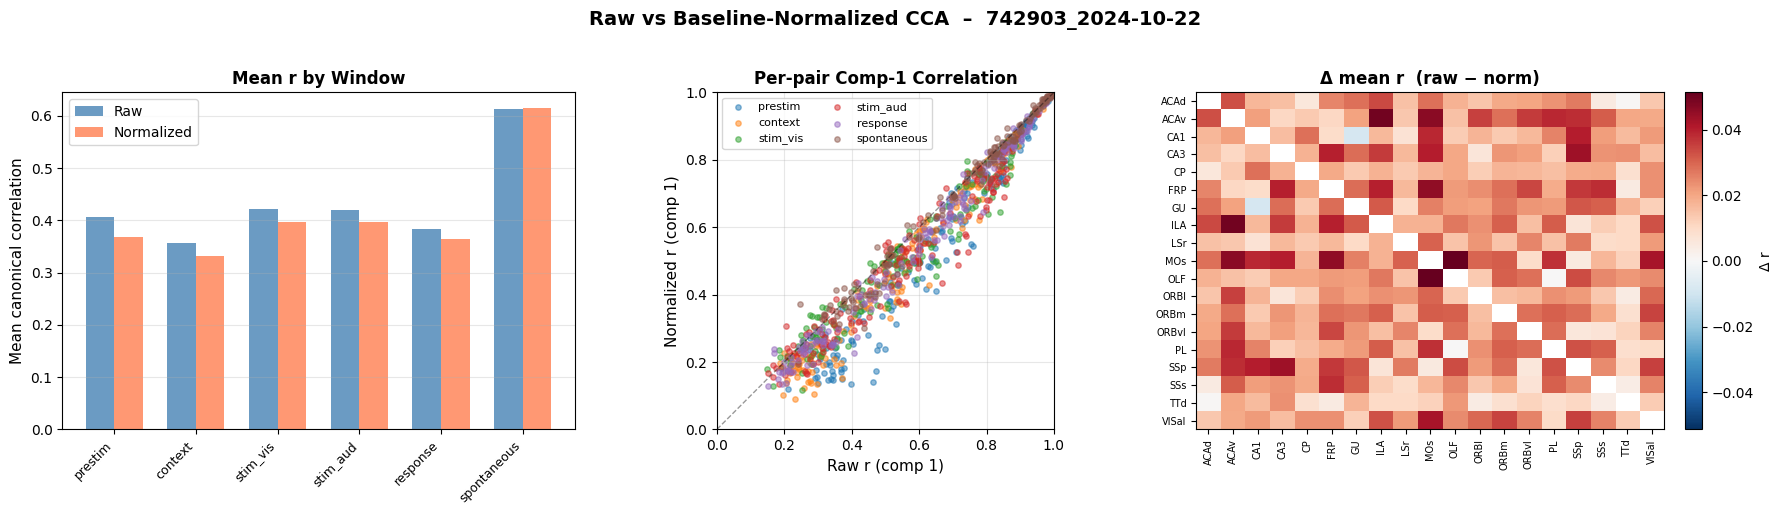

In [52]:
# ── Compare raw vs baseline-normalized CCA ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

window_order = list(CCA_WINDOWS.keys())

# ─── 1) Bar chart: mean r by window ───────────────────────────────────────────
raw_r  = [cca_results_df[cca_results_df['time_window'] == w]['r'].mean()
          for w in window_order]
norm_r = [cca_results_norm_df[cca_results_norm_df['time_window'] == w]['r'].mean()
          for w in window_order]

x = np.arange(len(window_order))
w = 0.35
axes[0].bar(x - w/2, raw_r,  w, label='Raw', color='steelblue', alpha=0.8)
axes[0].bar(x + w/2, norm_r, w, label='Normalized', color='coral', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(window_order, rotation=45, ha='right', fontsize=9)
axes[0].set_ylabel('Mean canonical correlation', fontsize=11)
axes[0].set_title('Mean r by Window', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', alpha=0.3)

# ─── 2) Scatter: raw r_comp1 vs normalized r_comp1 per pair ───────────────────
merged = summary_df.merge(
    summary_norm_df, on=['struct_A', 'struct_B', 'time_window'],
    suffixes=('_raw', '_norm')
)
for win in window_order:
    sub = merged[merged['time_window'] == win]
    axes[1].scatter(sub['r_comp1_raw'], sub['r_comp1_norm'],
                    alpha=0.5, s=15, label=win)
lims = [0, 1]
axes[1].plot(lims, lims, 'k--', alpha=0.4, linewidth=1)
axes[1].set_xlabel('Raw r (comp 1)', fontsize=11)
axes[1].set_ylabel('Normalized r (comp 1)', fontsize=11)
axes[1].set_title('Per-pair Comp-1 Correlation', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=8, ncol=2)
axes[1].set_xlim(lims); axes[1].set_ylim(lims)
axes[1].set_aspect('equal')
axes[1].grid(alpha=0.3)

# ─── 3) Delta heatmap (raw − normalized mean r, averaged over windows) ────────
delta_df = merged.copy()
delta_df['delta_mean_r'] = delta_df['mean_r_raw'] - delta_df['mean_r_norm']
delta_avg = (
    delta_df.groupby(['struct_A', 'struct_B'])['delta_mean_r'].mean().reset_index()
)
mat = make_symmetric_matrix(delta_avg, 'delta_mean_r', sorted(qualified_structures))
vabs = np.nanmax(np.abs(mat[~np.isnan(mat)])) if np.any(~np.isnan(mat)) else 0.1
im = axes[2].imshow(mat, vmin=-vabs, vmax=vabs, cmap='RdBu_r', aspect='auto')
axes[2].set_xticks(range(len(qualified_structures)))
axes[2].set_yticks(range(len(qualified_structures)))
axes[2].set_xticklabels(sorted(qualified_structures), rotation=90, fontsize=7)
axes[2].set_yticklabels(sorted(qualified_structures), fontsize=7)
axes[2].set_title('Δ mean r  (raw − norm)', fontsize=12, fontweight='bold')
fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04, label='Δ r')

plt.suptitle(f'Raw vs Baseline-Normalized CCA  –  {session_id}',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

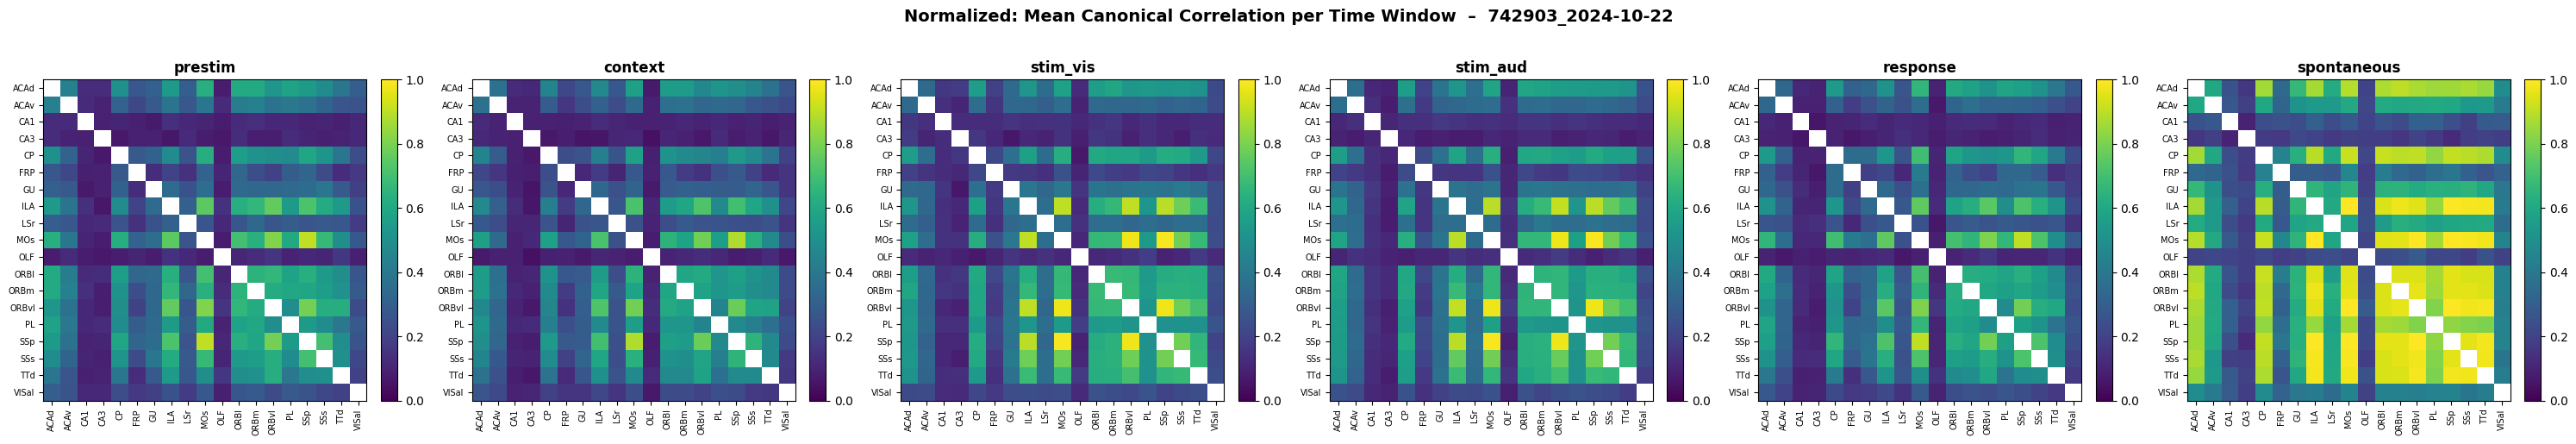

In [53]:
# ── Heatmaps: normalized mean canonical correlation per time window ─────────────
window_names_norm = list(CCA_WINDOWS.keys())
n_win_norm = len(window_names_norm)

fig, axes = plt.subplots(1, n_win_norm, figsize=(5 * n_win_norm, 5))

for ax, win_name in zip(axes, window_names_norm):
    sub = summary_norm_df[summary_norm_df['time_window'] == win_name]
    mat = make_symmetric_matrix(sub, 'mean_r', structs_sorted)
    im = ax.imshow(mat, vmin=0, vmax=1.0, cmap='viridis', aspect='auto')
    ax.set_xticks(range(len(structs_sorted)))
    ax.set_yticks(range(len(structs_sorted)))
    ax.set_xticklabels(structs_sorted, rotation=90, fontsize=7)
    ax.set_yticklabels(structs_sorted, fontsize=7)
    ax.set_title(win_name, fontsize=12, fontweight='bold')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle(f'Normalized: Mean Canonical Correlation per Time Window  –  {session_id}',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [54]:
# ── Save normalized CCA results ─────────────────────────────────────────────────
norm_comp_path = output_dir / f'cca_components_norm_{session_id}.parquet'
cca_results_norm_df.to_parquet(norm_comp_path, index=False)

norm_summary_path = output_dir / f'cca_summary_norm_{session_id}.parquet'
summary_norm_df.to_parquet(norm_summary_path, index=False)

print(f"Saved normalized components → {norm_comp_path}  ({cca_results_norm_df.shape})")
print(f"Saved normalized summary   → {norm_summary_path}  ({summary_norm_df.shape})")

Saved normalized components → ..\results\cca\cca_components_norm_742903_2024-10-22.parquet  ((8634, 14))
Saved normalized summary   → ..\results\cca\cca_summary_norm_742903_2024-10-22.parquet  ((1026, 12))


## 14. Compare CCA Dimensions to Task-Variable Coding Axes

For each brain area, compute 1-D coding axes (via LDA) for four task variables,
using **time-window-specific** activity:

**Pre-stimulus window (−0.2–0 s):**
1. **rewarded_modality** – visual vs auditory context (all task trials)

**Stimulus window (0–0.1 s):**
2. **visual stimulus discrimination** – vis1 vs vis2 (unrewarded blocks only, no-response trials)
3. **auditory stimulus discrimination** – sound1 vs sound2 (unrewarded blocks only, no-response trials)

**Response window (0.3–0.5 s):**
4. **is_response** – lick vs no-lick (all non-catch task trials)

Activity is z-scored and projected through the **same PCA basis** used for CCA.
PCA is fit on pooled data from **all time windows** (pre-stim, spontaneous, context,
stimulus, response) so the basis captures the full variance structure across epochs.

Angles between each coding axis and the first CCA canonical weight vector quantify
whether the inter-area "communication dimension" aligns with specific task-variable coding.

In [55]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

def angle_between_vectors(u, v, degrees=True):
    """Angle between two 1-D vectors (0–90°). Ignores sign ambiguity."""
    cos = np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v) + 1e-12)
    cos = np.clip(cos, -1.0, 1.0)
    angle = np.arccos(np.abs(cos))  # abs → range [0, 90°]
    return np.degrees(angle) if degrees else angle


def fit_coding_axis(X, labels, min_per_class=15):
    """
    Fit a 1-D LDA and return the unit-length weight vector in feature space.

    Parameters
    ----------
    X : (n_trials, n_features)
    labels : (n_trials,) binary-like labels
    min_per_class : int
        Minimum trials per class; returns None if not met.

    Returns
    -------
    axis : (n_features,) unit-norm vector, or None
    accuracy : float, leave-one-out accuracy (for sanity checking)
    n_per_class : dict
    """
    mask = ~pd.isna(labels)
    X, labels = X[mask], np.asarray(labels)[mask]
    classes, counts = np.unique(labels, return_counts=True)
    if len(classes) < 2 or np.any(counts < min_per_class):
        return None, np.nan, dict(zip(classes, counts))

    lda = LinearDiscriminantAnalysis(n_components=1, solver='svd')
    lda.fit(X, labels)
    axis = lda.coef_.flatten()
    axis = axis / (np.linalg.norm(axis) + 1e-12)

    # quick LOO accuracy estimate
    from sklearn.model_selection import cross_val_score
    acc = cross_val_score(
        LinearDiscriminantAnalysis(solver='svd'), X, labels,
        cv=min(5, min(counts)), scoring='accuracy'
    ).mean()

    return axis, acc, dict(zip(classes, counts))


print("Helper functions defined: angle_between_vectors(), fit_coding_axis()")

Helper functions defined: angle_between_vectors(), fit_coding_axis()


In [56]:
# ── Verify time-window PCA projections are available ───────────────────────────
# These were computed in §12 (struct_data) using PCA fit on all time windows.
# No additional work needed here — just confirm the projections exist.

for s, d in struct_data.items():
    assert 'context_pca' in d, f"Missing context_pca for {s}"
    assert 'stim_pca' in d, f"Missing stim_pca for {s}"
    assert 'resp_pca' in d, f"Missing resp_pca for {s}"

print("All time-window PCA projections available in struct_data.")
print(f"PCA was fit on pooled data from all windows (pre-stim + spont + context + stim + response).\n")
for s, d in struct_data.items():
    print(f"  {s:15s}  PCs={d['n_pc']:3d}  context={d['context_pca'].shape}  "
          f"stim={d['stim_pca'].shape}  resp={d['resp_pca'].shape}")

All time-window PCA projections available in struct_data.
PCA was fit on pooled data from all windows (pre-stim + spont + context + stim + response).

  ACAd             PCs= 30  context=(538, 30)  stim=(538, 30)  resp=(538, 30)
  ACAv             PCs= 17  context=(538, 17)  stim=(538, 17)  resp=(538, 17)
  CA1              PCs=  7  context=(538, 7)  stim=(538, 7)  resp=(538, 7)
  CA3              PCs=  4  context=(538, 4)  stim=(538, 4)  resp=(538, 4)
  CP               PCs= 34  context=(538, 34)  stim=(538, 34)  resp=(538, 34)
  FRP              PCs=  8  context=(538, 8)  stim=(538, 8)  resp=(538, 8)
  GU               PCs= 20  context=(538, 20)  stim=(538, 20)  resp=(538, 20)
  ILA              PCs= 83  context=(538, 83)  stim=(538, 83)  resp=(538, 83)
  LSr              PCs= 19  context=(538, 19)  stim=(538, 19)  resp=(538, 19)
  MOs              PCs=161  context=(538, 161)  stim=(538, 161)  resp=(538, 161)
  OLF              PCs=  5  context=(538, 5)  stim=(538, 5)  resp=(538, 5)


In [57]:
# ── Compute coding axes for every qualifying structure ──────────────────────────
# Uses time-window-specific PCA projections so that each coding axis is
# fit on the appropriate post-stimulus epoch.
# 'cca_window' maps each variable to the matching CCA window name in CCA_WINDOWS.

task_variable_defs = {
    'rewarded_modality': {
        'description': 'Visual vs auditory context (all task trials, -0.2-0 s)',
        'trial_filter': lambda t: t.index,  # all trials
        'label_col': 'rewarded_modality',
        'pca_key': 'context_pca',
        'cca_window': 'context',
    },
    'vis_stim_discrim': {
        'description': 'vis1 vs vis2 (unrewarded blocks, no-response, 0-0.1 s)',
        'trial_filter': lambda t: t.query(
            'rewarded_modality=="aud" and is_response==False and is_vis_stim==True'
        ).index,
        'label_col': 'stim_name',
        'pca_key': 'stim_pca',
        'cca_window': 'stim_vis',
    },
    'aud_stim_discrim': {
        'description': 'sound1 vs sound2 (unrewarded blocks, no-response, 0-0.1 s)',
        'trial_filter': lambda t: t.query(
            'rewarded_modality=="vis" and is_response==False and is_aud_stim==True'
        ).index,
        'label_col': 'stim_name',
        'pca_key': 'stim_pca',
        'cca_window': 'stim_aud',
    },
    'is_response': {
        'description': 'Lick vs no-lick (all non-catch task trials, 0.3-0.5 s)',
        'trial_filter': lambda t: t.query('is_catch==False').index,
        'label_col': 'is_response',
        'pca_key': 'resp_pca',
        'cca_window': 'response',
    },
}

# For each structure, compute coding axes in its PCA space
coding_axes = {}

for struct, sd in struct_data.items():
    coding_axes[struct] = {}

    for var_name, var_def in task_variable_defs.items():
        X_pca = sd[var_def['pca_key']]

        trial_idx = var_def['trial_filter'](trials)
        trial_positions = np.isin(np.arange(len(trials)), trial_idx)

        X_sub = X_pca[trial_positions]
        labels = trials.loc[trials.index[trial_positions], var_def['label_col']].values

        axis, acc, n_per_class = fit_coding_axis(X_sub, labels)
        coding_axes[struct][var_name] = {
            'axis': axis,
            'accuracy': acc,
            'n_per_class': n_per_class,
        }

# Print summary
print(f"{'Structure':<15s}  {'Variable':<20s}  {'CCA window':>10s}  {'Accuracy':>8s}  {'Trials/class'}")
print('-' * 90)
for struct in sorted(coding_axes.keys()):
    for var_name, var_def in task_variable_defs.items():
        info = coding_axes[struct][var_name]
        status = f"{info['accuracy']:.2f}" if info['axis'] is not None else 'SKIP'
        print(f"{struct:<15s}  {var_name:<20s}  {var_def['cca_window']:>10s}  {status:>8s}  {info['n_per_class']}")

Structure        Variable              CCA window  Accuracy  Trials/class
------------------------------------------------------------------------------------------
ACAd             rewarded_modality        context      0.74  {'aud': 269, 'vis': 269}
ACAd             vis_stim_discrim        stim_vis      0.90  {'vis1': 47, 'vis2': 56}
ACAd             aud_stim_discrim        stim_aud      0.67  {'sound1': 47, 'sound2': 58}
ACAd             is_response             response      0.90  {False: 333, True: 162}
ACAv             rewarded_modality        context      0.63  {'aud': 269, 'vis': 269}
ACAv             vis_stim_discrim        stim_vis      0.62  {'vis1': 47, 'vis2': 56}
ACAv             aud_stim_discrim        stim_aud      0.45  {'sound1': 47, 'sound2': 58}
ACAv             is_response             response      0.80  {False: 333, True: 162}
CA1              rewarded_modality        context      0.56  {'aud': 269, 'vis': 269}
CA1              vis_stim_discrim        stim_vis      

In [58]:
# ── Compute angles between coding axes and CCA canonical vectors ────────────────
# For each task variable, CCA is fit on the MATCHING time window (including
# modality-specific trial masks for stimulus windows) so that the CCA dimension
# and coding axis are estimated from the same epoch and trial set.

N_PERM = 10  # label-shuffle permutations for null distribution

angle_records = []

for sA, sB in combinations(qualified_structures, 2):
    dA, dB = struct_data[sA], struct_data[sB]

    for var_name, var_def in task_variable_defs.items():
        pca_key = var_def['pca_key']
        cca_win = var_def['cca_window']
        cca_pca_key, cca_trial_mask = CCA_WINDOWS[cca_win]

        # Get PCA data with the CCA trial mask applied
        A_cca, B_cca = dA[cca_pca_key], dB[cca_pca_key]
        if cca_trial_mask is not None and cca_pca_key != 'spont_pca':
            mask = np.asarray(cca_trial_mask, dtype=bool)
            A_cca, B_cca = A_cca[mask], B_cca[mask]

        A_m, B_m, d = match_dims(A_cca, B_cca)
        k = min(MAX_CCA_COMPS, d, A_m.shape[0] - 1, B_m.shape[0] - 1)
        if k < 1:
            continue
        try:
            cca, _, _ = run_cca(A_m, B_m, n_components=k)
        except Exception:
            continue

        w_A = cca.x_weights_[:, 0]
        w_B = cca.y_weights_[:, 0]

        for struct_label, w_cca, sd in [('A', w_A, dA), ('B', w_B, dB)]:
            struct_name = sA if struct_label == 'A' else sB
            info = coding_axes[struct_name][var_name]
            coding_ax = info['axis']
            if coding_ax is None:
                continue

            coding_ax_trunc = coding_ax[:len(w_cca)]
            if np.linalg.norm(coding_ax_trunc) < 1e-8:
                continue
            coding_ax_trunc = coding_ax_trunc / np.linalg.norm(coding_ax_trunc)

            observed_angle = angle_between_vectors(w_cca, coding_ax_trunc)

            # ── Null distribution: shuffle labels, refit LDA ───────────────
            trial_idx = var_def['trial_filter'](trials)
            trial_positions = np.isin(np.arange(len(trials)), trial_idx)
            X_pca_full = sd[pca_key]
            X_sub = X_pca_full[trial_positions]
            labels = trials.loc[trials.index[trial_positions], var_def['label_col']].values
            valid = ~pd.isna(labels)
            X_sub, labels = X_sub[valid], labels[valid]

            null_angles = []
            for _ in range(N_PERM):
                shuf_labels = np.random.permutation(labels)
                ax_shuf, _, _ = fit_coding_axis(X_sub, shuf_labels, min_per_class=5)
                if ax_shuf is None:
                    continue
                ax_shuf_trunc = ax_shuf[:len(w_cca)]
                if np.linalg.norm(ax_shuf_trunc) < 1e-8:
                    continue
                ax_shuf_trunc = ax_shuf_trunc / np.linalg.norm(ax_shuf_trunc)
                null_angles.append(angle_between_vectors(w_cca, ax_shuf_trunc))

            null_angles = np.array(null_angles) if null_angles else np.array([np.nan])
            p_value = np.mean(null_angles <= observed_angle) if len(null_angles) > 1 else np.nan

            angle_records.append({
                'struct_A': sA,
                'struct_B': sB,
                'struct_role': struct_label,
                'structure': struct_name,
                'variable': var_name,
                'cca_window': cca_win,
                'time_window': {
                    'context_pca': '-0.2-0s', 'stim_pca': '0-0.1s', 'resp_pca': '0.3-0.5s'
                }[pca_key],
                'observed_angle_deg': observed_angle,
                'null_mean_deg': np.nanmean(null_angles),
                'null_std_deg': np.nanstd(null_angles),
                'p_value': p_value,
                'coding_accuracy': info['accuracy'],
                'n_per_class': str(info['n_per_class']),
            })

print(f"Computed {len(angle_records)} angle measurements "
      f"({N_PERM} permutations each for null).")
print(f"CCA is fit on the MATCHING time window + trial subset per variable.")

c:\Anaconda3\envs\dr_ibl_analysis\Lib\site-packages\sklearn\cross_decomposition\_pls.py:113: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)
c:\Anaconda3\envs\dr_ibl_analysis\Lib\site-packages\sklearn\cross_decomposition\_pls.py:113: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)
c:\Anaconda3\envs\dr_ibl_analysis\Lib\site-packages\sklearn\cross_decomposition\_pls.py:113: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)
c:\Anaconda3\envs\dr_ibl_analysis\Lib\site-packages\sklearn\cross_decomposition\_pls.py:113: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)
c:\Anaconda3\envs\dr_ibl_analysis\Lib\site-packages\sklearn\cross_decomposition\_pls.py:113: Con

Computed 1368 angle measurements (10 permutations each for null).
CCA is fit on the MATCHING time window + trial subset per variable.


In [59]:
# ── Build results DataFrame ─────────────────────────────────────────────────────
angles_df = pd.DataFrame(angle_records)

# Flag significant results (observed angle < null at p < 0.05)
angles_df['significant'] = angles_df['p_value'] < 0.05

print(f"Shape: {angles_df.shape}")
print(f"\nSignificant alignments (p < 0.05): "
      f"{angles_df['significant'].sum()} / {len(angles_df)}")
print(f"\nSummary by variable:")
print(
    angles_df.groupby('variable').agg(
        mean_angle=('observed_angle_deg', 'mean'),
        mean_null=('null_mean_deg', 'mean'),
        n_sig=('significant', 'sum'),
        n_total=('significant', 'count'),
        mean_accuracy=('coding_accuracy', 'mean'),
    ).round(2)
)

angles_df.head(10)

Shape: (1368, 14)

Significant alignments (p < 0.05): 503 / 1368

Summary by variable:
                   mean_angle  mean_null  n_sig  n_total  mean_accuracy
variable                                                               
aud_stim_discrim        74.41      75.35     31      342           0.56
is_response             52.32      77.56    236      342           0.83
rewarded_modality       63.16      77.04    169      342           0.65
vis_stim_discrim        71.84      75.63     67      342           0.64


,struct_A,struct_B,struct_role,structure,variable,cca_window,time_window,observed_angle_deg,null_mean_deg,null_std_deg,p_value,coding_accuracy,n_per_class,significant
0,ACAd,ACAv,A,ACAd,rewarded_modality,context,-0.2-0s,86.823966,83.589449,5.801427,0.6,0.735566,"{'aud': 269, 'vis': 269}",False
1,ACAd,ACAv,B,ACAv,rewarded_modality,context,-0.2-0s,84.955989,83.631271,7.856621,0.4,0.628228,"{'aud': 269, 'vis': 269}",False
2,ACAd,ACAv,A,ACAd,vis_stim_discrim,stim_vis,0-0.1s,78.344479,78.635372,8.044855,0.5,0.902381,"{'vis1': 47, 'vis2': 56}",False
3,ACAd,ACAv,B,ACAv,vis_stim_discrim,stim_vis,0-0.1s,51.945240,76.850280,8.862998,0.0,0.622381,"{'vis1': 47, 'vis2': 56}",True
4,ACAd,ACAv,A,ACAd,aud_stim_discrim,stim_aud,0-0.1s,87.823116,86.893830,1.408554,0.7,0.666667,"{'sound1': 47, 'sound2': 58}",False
5,ACAd,ACAv,B,ACAv,aud_stim_discrim,stim_aud,0-0.1s,84.447599,81.354588,5.770768,0.6,0.447619,"{'sound1': 47, 'sound2': 58}",False
6,ACAd,ACAv,A,ACAd,is_response,response,0.3-0.5s,78.518052,80.832933,4.949549,0.4,0.903030,"{False: 333, True: 162}",False
7,ACAd,ACAv,B,ACAv,is_response,response,0.3-0.5s,83.888321,82.795693,3.704796,0.6,0.800000,"{False: 333, True: 162}",False
8,ACAd,CA1,A,ACAd,rewarded_modality,context,-0.2-0s,77.952469,63.463215,10.208858,0.9,0.735566,"{'aud': 269, 'vis': 269}",False
9,ACAd,CA1,B,CA1,rewarded_modality,context,-0.2-0s,75.567233,67.579478,9.401233,0.8,0.557511,"{'aud': 269, 'vis': 269}",False


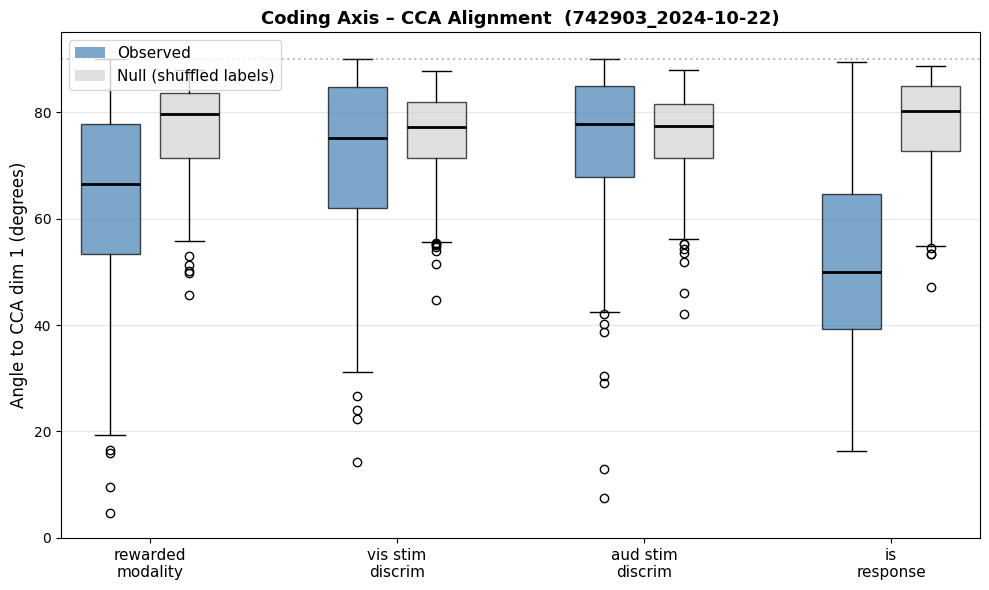

In [60]:
# ── Boxplot: observed angles vs null, grouped by task variable ──────────────────
fig, ax = plt.subplots(figsize=(10, 6))

var_names = list(task_variable_defs.keys())
var_labels = ['rewarded\nmodality', 'vis stim\ndiscrim', 'aud stim\ndiscrim', 'is\nresponse']

positions_obs = np.arange(len(var_names)) * 2.5
positions_null = positions_obs + 0.8

# Observed angles
bp_obs = ax.boxplot(
    [angles_df.loc[angles_df['variable'] == v, 'observed_angle_deg'].dropna().values
     for v in var_names],
    positions=positions_obs, widths=0.6, patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.7),
    medianprops=dict(color='black', linewidth=2),
)

# Null angles
bp_null = ax.boxplot(
    [angles_df.loc[angles_df['variable'] == v, 'null_mean_deg'].dropna().values
     for v in var_names],
    positions=positions_null, widths=0.6, patch_artist=True,
    boxprops=dict(facecolor='lightgray', alpha=0.7),
    medianprops=dict(color='black', linewidth=2),
)

ax.set_xticks((positions_obs + positions_null) / 2)
ax.set_xticklabels(var_labels, fontsize=11)
ax.set_ylabel('Angle to CCA dim 1 (degrees)', fontsize=12)
ax.set_title(f'Coding Axis – CCA Alignment  ({session_id})', fontsize=13, fontweight='bold')
ax.set_ylim([0, 95])
ax.axhline(90, color='gray', linestyle=':', alpha=0.5)

# Legend
from matplotlib.patches import Patch
ax.legend(
    [Patch(facecolor='steelblue', alpha=0.7), Patch(facecolor='lightgray', alpha=0.7)],
    ['Observed', 'Null (shuffled labels)'],
    fontsize=11, loc='upper left'
)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

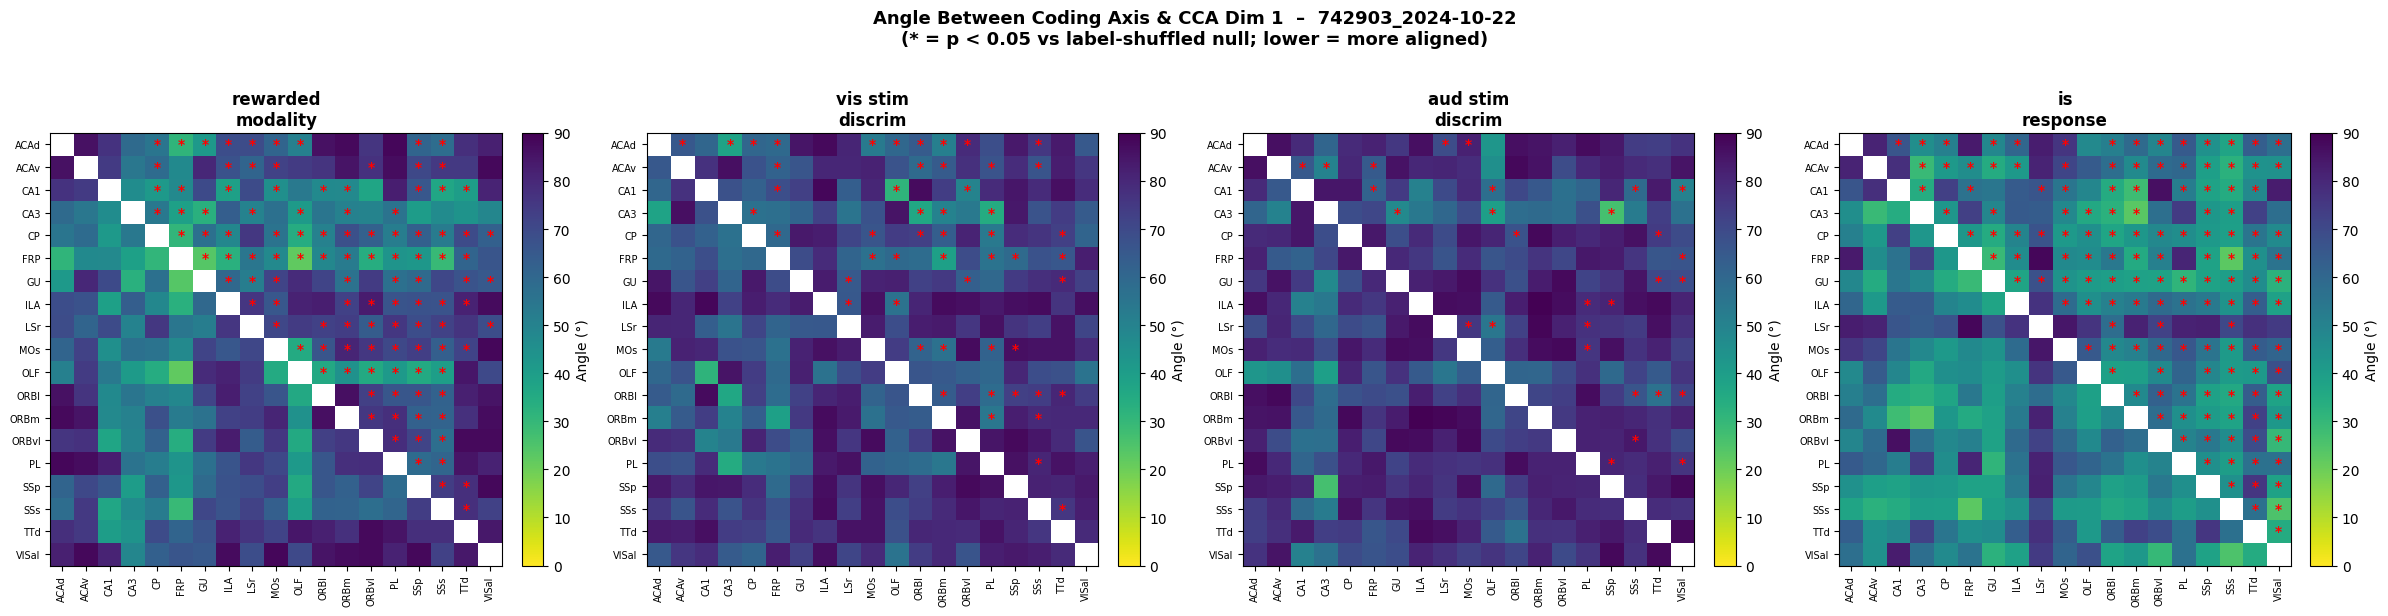

In [61]:
# ── Heatmaps: angle between coding axis and CCA dim 1 for each area pair ───────
# Average over struct_role (A and B) to get one value per (pair, variable).

pair_var_angles = (
    angles_df
    .groupby(['struct_A', 'struct_B', 'variable'])
    .agg(
        mean_angle=('observed_angle_deg', 'mean'),
        mean_null=('null_mean_deg', 'mean'),
        min_p=('p_value', 'min'),
    )
    .reset_index()
)

fig, axes = plt.subplots(1, len(var_names), figsize=(6 * len(var_names), 6))

for ax, var_name, var_label in zip(axes, var_names, var_labels):
    sub = pair_var_angles[pair_var_angles['variable'] == var_name]
    mat = make_symmetric_matrix(sub, 'mean_angle', sorted(qualified_structures))

    im = ax.imshow(mat, vmin=0, vmax=90, cmap='viridis_r', aspect='auto')
    ax.set_xticks(range(len(qualified_structures)))
    ax.set_yticks(range(len(qualified_structures)))
    ax.set_xticklabels(sorted(qualified_structures), rotation=90, fontsize=7)
    ax.set_yticklabels(sorted(qualified_structures), fontsize=7)
    ax.set_title(var_label, fontsize=12, fontweight='bold')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Angle (°)')

    # Mark significant pairs
    sorted_structs = sorted(qualified_structures)
    idx_map = {s: i for i, s in enumerate(sorted_structs)}
    sig_sub = sub[sub['min_p'] < 0.05]
    for _, row in sig_sub.iterrows():
        if row['struct_A'] in idx_map and row['struct_B'] in idx_map:
            i, j = idx_map[row['struct_A']], idx_map[row['struct_B']]
            ax.text(j, i, '*', ha='center', va='center', color='red',
                    fontsize=10, fontweight='bold')

plt.suptitle(
    f'Angle Between Coding Axis & CCA Dim 1  –  {session_id}\n'
    f'(* = p < 0.05 vs label-shuffled null; lower = more aligned)',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

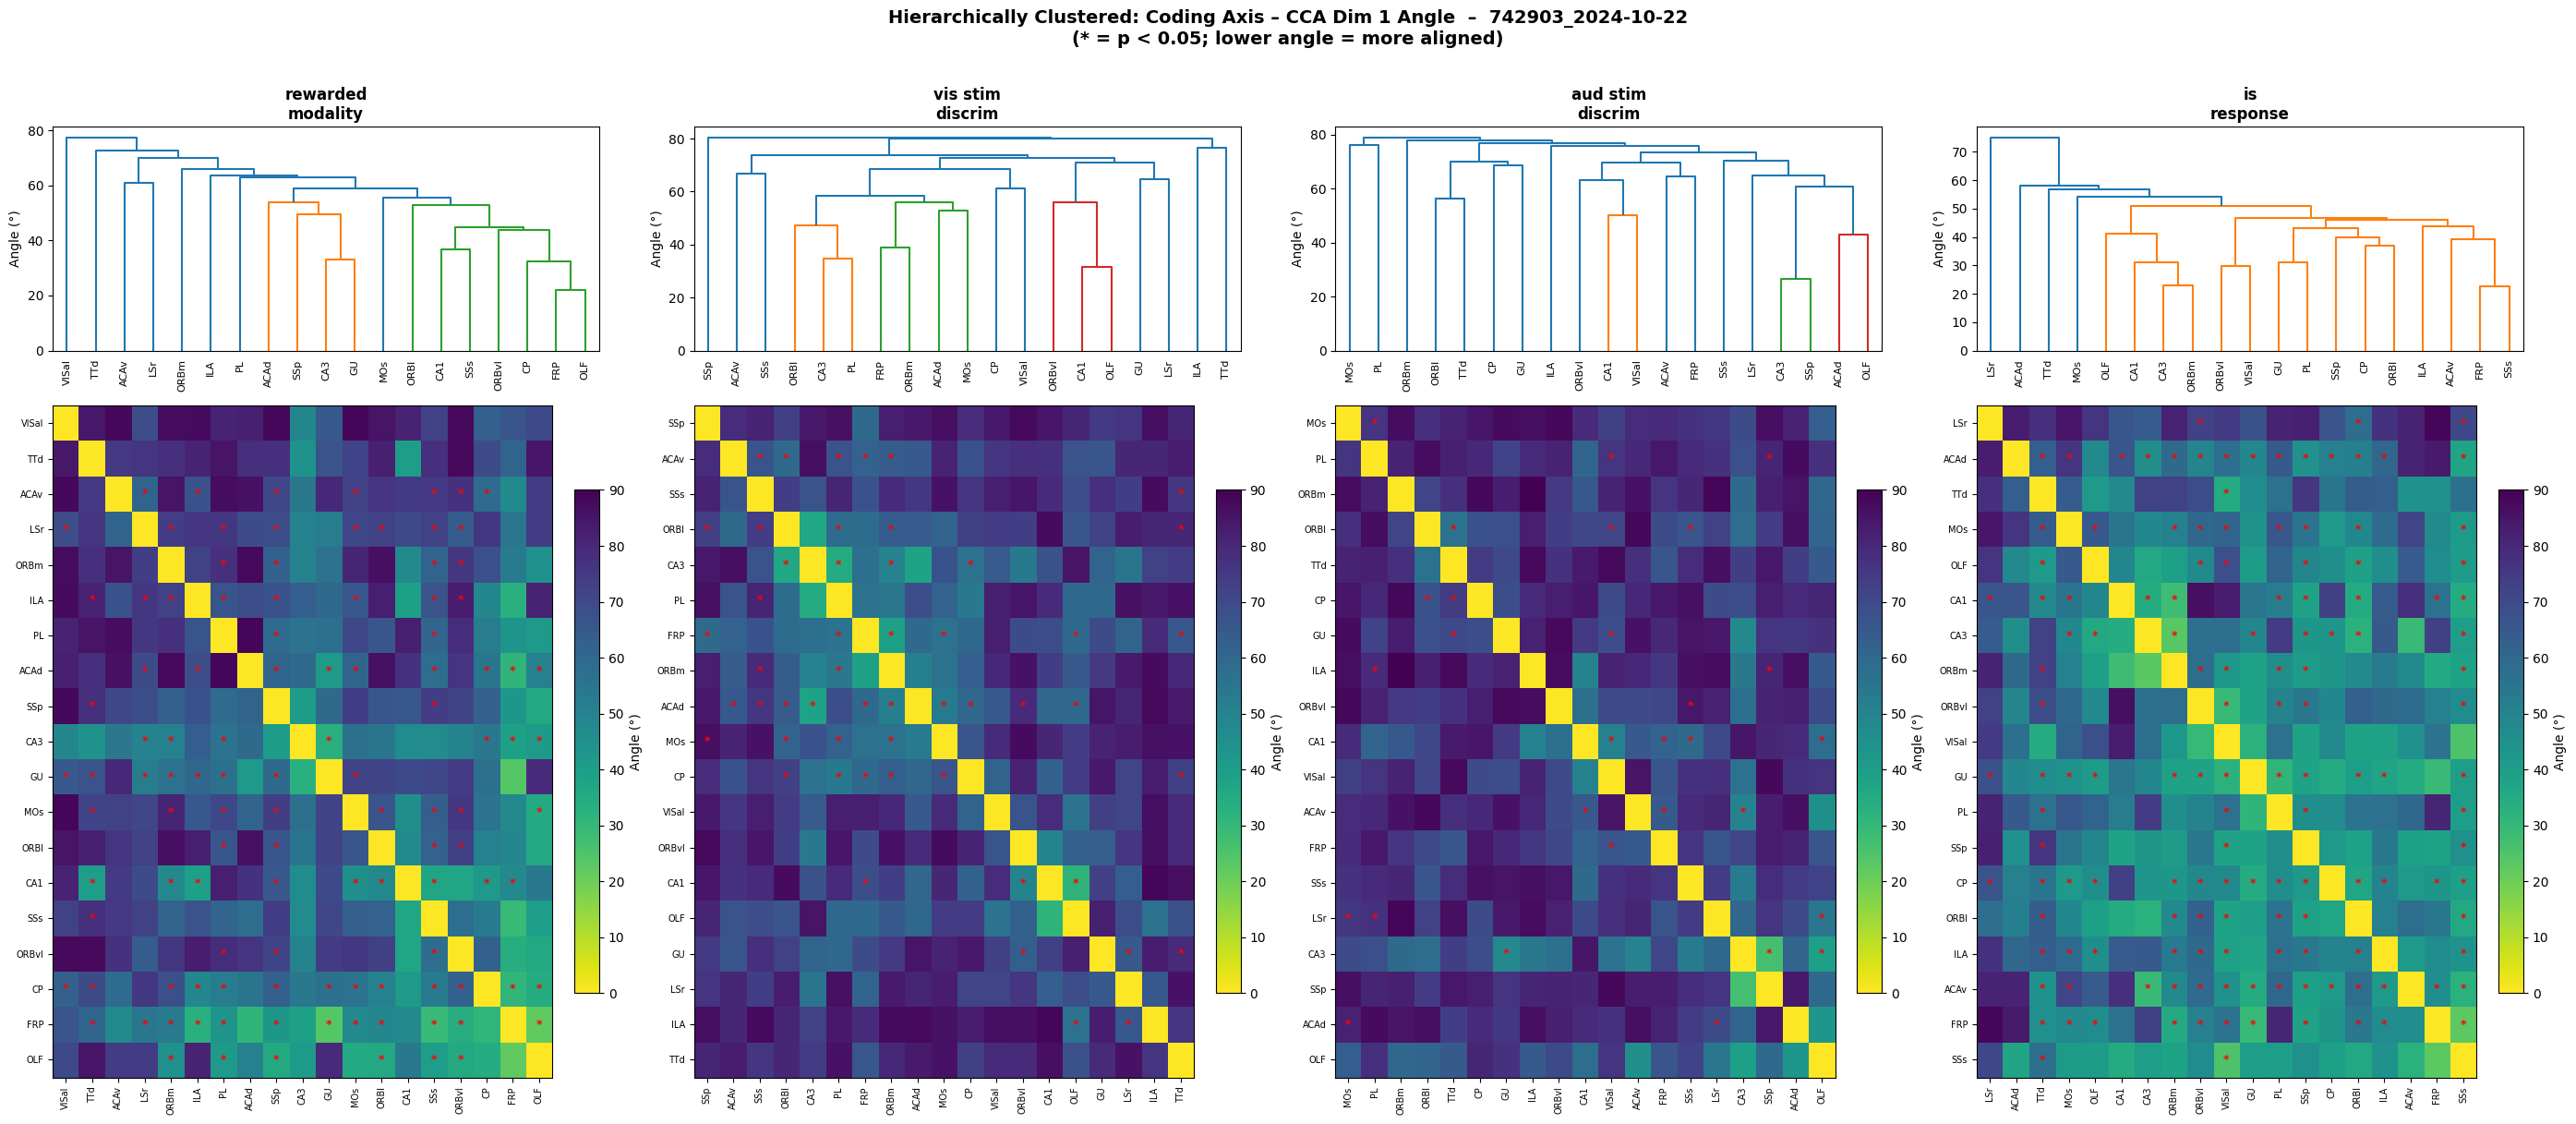


rewarded modality  (10 clusters):
  Cluster 1: ACAv
  Cluster 2: LSr
  Cluster 3: ACAd, CA3, GU, SSp
  Cluster 4: CA1, CP, FRP, OLF, ORBl, ORBvl, SSs
  Cluster 5: MOs
  Cluster 6: PL
  Cluster 7: ILA
  Cluster 8: ORBm
  Cluster 9: TTd
  Cluster 10: VISal

vis stim discrim  (12 clusters):
  Cluster 1: ACAv
  Cluster 2: SSs
  Cluster 3: CA3, ORBl, PL
  Cluster 4: ACAd, FRP, MOs, ORBm
  Cluster 5: CP
  Cluster 6: VISal
  Cluster 7: CA1, OLF, ORBvl
  Cluster 8: GU
  Cluster 9: LSr
  Cluster 10: ILA
  Cluster 11: TTd
  Cluster 12: SSp

aud stim discrim  (16 clusters):
  Cluster 1: MOs
  Cluster 2: PL
  Cluster 3: ORBl
  Cluster 4: TTd
  Cluster 5: CP
  Cluster 6: GU
  Cluster 7: CA1, VISal
  Cluster 8: ORBvl
  Cluster 9: ACAv
  Cluster 10: FRP
  Cluster 11: CA3, SSp
  Cluster 12: ACAd, OLF
  Cluster 13: LSr
  Cluster 14: SSs
  Cluster 15: ILA
  Cluster 16: ORBm

is response  (5 clusters):
  Cluster 1: ACAv, CA1, CA3, CP, FRP, GU, ILA, OLF, ORBl, ORBm, ORBvl, PL, SSp, SSs, VISal
  Cluster 2

In [65]:
# ── Hierarchically clustered heatmaps per coding axis ──────────────────────────
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform

sorted_structs = sorted(qualified_structures)
n_structs = len(sorted_structs)

# Build one symmetric distance matrix per variable and cluster
cluster_assignments = {}  # var_name → {struct: cluster_id}
linkages = {}

fig, axes = plt.subplots(2, len(var_names), figsize=(7 * len(var_names), 12),
                         gridspec_kw={'height_ratios': [1, 3]})

for col, (var_name, var_label) in enumerate(zip(var_names, var_labels)):
    sub = pair_var_angles[pair_var_angles['variable'] == var_name]
    mat = make_symmetric_matrix(sub, 'mean_angle', sorted_structs)

    # Replace NaN diagonal with 0 (self-distance)
    np.fill_diagonal(mat, 0)
    # Replace remaining NaNs with 90 (max possible angle = no info)
    mat = np.nan_to_num(mat, nan=90.0)

    # Hierarchical clustering (average linkage on the angle matrix as distance)
    condensed = squareform(mat, checks=False)
    Z = linkage(condensed, method='average')
    linkages[var_name] = Z

    # Dendrogram (top row)
    ax_dend = axes[0, col]
    dend = dendrogram(Z, labels=sorted_structs, ax=ax_dend,
                      leaf_rotation=90, leaf_font_size=8,
                      color_threshold=0.7 * max(Z[:, 2]))
    ax_dend.set_title(var_label, fontsize=12, fontweight='bold')
    ax_dend.set_ylabel('Angle (°)')

    # Reorder matrix by dendrogram leaves
    order = dend['leaves']
    ordered_structs = [sorted_structs[i] for i in order]
    mat_ordered = mat[np.ix_(order, order)]

    # Clustered heatmap (bottom row)
    ax_heat = axes[1, col]
    im = ax_heat.imshow(mat_ordered, vmin=0, vmax=90, cmap='viridis_r', aspect='auto')
    ax_heat.set_xticks(range(n_structs))
    ax_heat.set_yticks(range(n_structs))
    ax_heat.set_xticklabels(ordered_structs, rotation=90, fontsize=7)
    ax_heat.set_yticklabels(ordered_structs, fontsize=7)
    fig.colorbar(im, ax=ax_heat, fraction=0.046, pad=0.04, label='Angle (°)')

    # Mark significant pairs on reordered matrix
    sig_sub = sub[sub['min_p'] < 0.05]
    ordered_idx = {s: i for i, s in enumerate(ordered_structs)}
    for _, row in sig_sub.iterrows():
        if row['struct_A'] in ordered_idx and row['struct_B'] in ordered_idx:
            ri, ci = ordered_idx[row['struct_A']], ordered_idx[row['struct_B']]
            ax_heat.text(ci, ri, '*', ha='center', va='center', color='red',
                         fontsize=9, fontweight='bold')

    # Cut dendrogram into clusters (using a threshold at 70% of max merge distance)
    threshold = 0.7 * max(Z[:, 2])
    labels_cl = fcluster(Z, t=threshold, criterion='distance')
    cluster_assignments[var_name] = {s: int(c) for s, c in zip(sorted_structs, labels_cl)}

plt.suptitle(
    f'Hierarchically Clustered: Coding Axis – CCA Dim 1 Angle  –  {session_id}\n'
    f'(* = p < 0.05; lower angle = more aligned)',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

# Print cluster assignments
for var_name, var_label in zip(var_names, var_labels):
    ca = cluster_assignments[var_name]
    n_cl = len(set(ca.values()))
    print(f"\n{var_label.replace(chr(10),' ')}  ({n_cl} clusters):")
    for cl_id in sorted(set(ca.values())):
        members = [s for s, c in ca.items() if c == cl_id]
        print(f"  Cluster {cl_id}: {', '.join(members)}")

Cluster assignments per structure:
       rewarded modality  vis stim discrim  aud stim discrim  is response
ACAd                   3                 4                12            4
ACAv                   1                 1                 9            1
CA1                    4                 7                 7            1
CA3                    3                 3                11            1
CP                     4                 5                 5            1
FRP                    4                 4                10            1
GU                     3                 8                 6            1
ILA                    7                10                15            1
LSr                    2                 9                13            5
MOs                    5                 4                 1            2
OLF                    4                 7                12            1
ORBl                   4                 3                 3            1
ORB

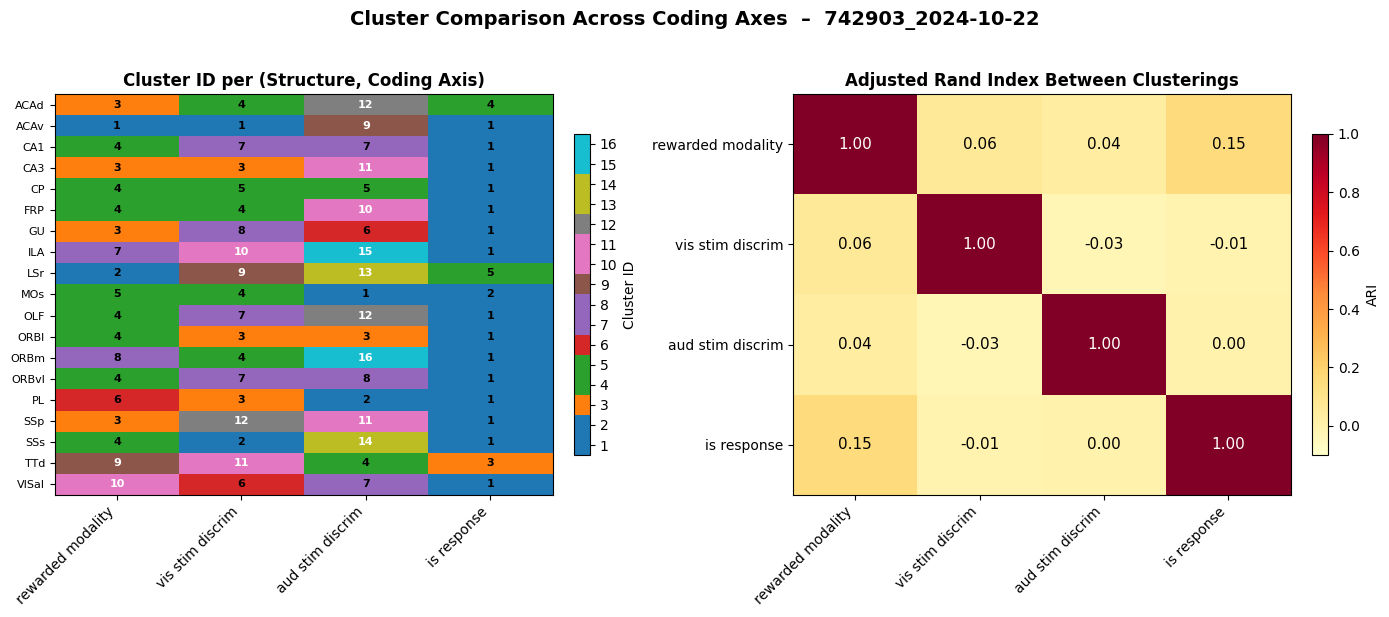

In [67]:
# ── Compare cluster assignments across coding axes ─────────────────────────────
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score

# 1) Build a structure × variable cluster-ID matrix for visualization
cluster_matrix = pd.DataFrame(cluster_assignments, index=sorted_structs)
cluster_matrix.columns = [vl.replace('\n', ' ') for vl in var_labels]

print("Cluster assignments per structure:")
print(cluster_matrix.to_string())

# 2) Pairwise similarity of clusterings across coding axes (ARI & AMI)
ari_records = []
for i, v1 in enumerate(var_names):
    for j, v2 in enumerate(var_names):
        if j <= i:
            continue
        labels1 = [cluster_assignments[v1][s] for s in sorted_structs]
        labels2 = [cluster_assignments[v2][s] for s in sorted_structs]
        ari = adjusted_rand_score(labels1, labels2)
        ami = adjusted_mutual_info_score(labels1, labels2)
        ari_records.append({
            'axis_1': var_labels[i].replace('\n', ' '),
            'axis_2': var_labels[j].replace('\n', ' '),
            'ARI': round(ari, 3),
            'AMI': round(ami, 3),
        })

ari_df = pd.DataFrame(ari_records)
print("\nPairwise clustering similarity (ARI / AMI):")
print(ari_df.to_string(index=False))

# 3) Heatmap of cluster-ID matrix + cross-axis ARI matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: structure × variable cluster assignment
n_clusters_max = int(cluster_matrix.max().max())
cmap_cl = plt.colormaps.get_cmap('tab10').resampled(n_clusters_max)
im1 = axes[0].imshow(cluster_matrix.values, aspect='auto', cmap=cmap_cl,
                      vmin=0.5, vmax=n_clusters_max + 0.5)
axes[0].set_xticks(range(len(cluster_matrix.columns)))
axes[0].set_yticks(range(len(sorted_structs)))
axes[0].set_xticklabels(cluster_matrix.columns, rotation=45, ha='right', fontsize=10)
axes[0].set_yticklabels(sorted_structs, fontsize=8)
axes[0].set_title('Cluster ID per (Structure, Coding Axis)', fontsize=12, fontweight='bold')
for yi in range(len(sorted_structs)):
    for xi in range(len(cluster_matrix.columns)):
        axes[0].text(xi, yi, str(cluster_matrix.values[yi, xi]),
                     ha='center', va='center', fontsize=8, fontweight='bold',
                     color='white' if cluster_matrix.values[yi, xi] > n_clusters_max / 2 else 'black')
fig.colorbar(im1, ax=axes[0], fraction=0.03, pad=0.04, label='Cluster ID',
             ticks=range(1, n_clusters_max + 1))

# Right: cross-axis ARI matrix
axis_labels_short = [vl.replace('\n', ' ') for vl in var_labels]
n_ax = len(axis_labels_short)
ari_mat = np.eye(n_ax)
for _, row in ari_df.iterrows():
    i = axis_labels_short.index(row['axis_1'])
    j = axis_labels_short.index(row['axis_2'])
    ari_mat[i, j] = ari_mat[j, i] = row['ARI']

im2 = axes[1].imshow(ari_mat, vmin=-0.1, vmax=1.0, cmap='YlOrRd', aspect='auto')
axes[1].set_xticks(range(n_ax))
axes[1].set_yticks(range(n_ax))
axes[1].set_xticklabels(axis_labels_short, rotation=45, ha='right', fontsize=10)
axes[1].set_yticklabels(axis_labels_short, fontsize=10)
axes[1].set_title('Adjusted Rand Index Between Clusterings', fontsize=12, fontweight='bold')
for yi in range(n_ax):
    for xi in range(n_ax):
        axes[1].text(xi, yi, f'{ari_mat[yi, xi]:.2f}', ha='center', va='center',
                     fontsize=11, color='white' if ari_mat[yi, xi] > 0.5 else 'black')
fig.colorbar(im2, ax=axes[1], fraction=0.03, pad=0.04, label='ARI')

plt.suptitle(f'Cluster Comparison Across Coding Axes  –  {session_id}',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [62]:
# ── Best-aligned task variable per area pair ────────────────────────────────────
# For each (struct_A, struct_B) pair, which task variable's coding axis is most
# aligned (smallest angle) with CCA dim 1?

best_aligned = (
    pair_var_angles
    .loc[pair_var_angles.groupby(['struct_A', 'struct_B'])['mean_angle'].idxmin()]
    [['struct_A', 'struct_B', 'variable', 'mean_angle', 'min_p']]
    .sort_values('mean_angle')
    .reset_index(drop=True)
)

print("Best-aligned task variable per area pair (smallest angle to CCA dim 1):\n")
print(best_aligned.to_string(index=False))

# Count how often each variable is best-aligned
print(f"\n\nFrequency of best-aligned variable:")
print(best_aligned['variable'].value_counts().to_string())

Best-aligned task variable per area pair (smallest angle to CCA dim 1):

struct_A struct_B          variable  mean_angle  min_p
     FRP      OLF rewarded_modality   21.857073    0.0
     FRP      SSs       is_response   22.610989    0.0
     CA3     ORBm       is_response   22.905583    0.0
     FRP       GU rewarded_modality   23.593676    0.0
     SSs    VISal       is_response   25.161955    0.0
     CA3      SSp  aud_stim_discrim   26.429719    0.0
     CA1     ORBm       is_response   27.818979    0.0
    ACAv      CA3       is_response   29.096509    0.0
   ORBvl    VISal       is_response   29.761000    0.0
      CP      FRP rewarded_modality   30.702577    0.0
    ACAd      FRP rewarded_modality   30.982339    0.0
      GU       PL       is_response   31.040105    0.0
     CA1      OLF  vis_stim_discrim   31.492927    0.0
      GU    VISal       is_response   32.126818    0.0
    ACAv      SSs       is_response   32.499993    0.0
     CA3     ORBl       is_response   32.574733

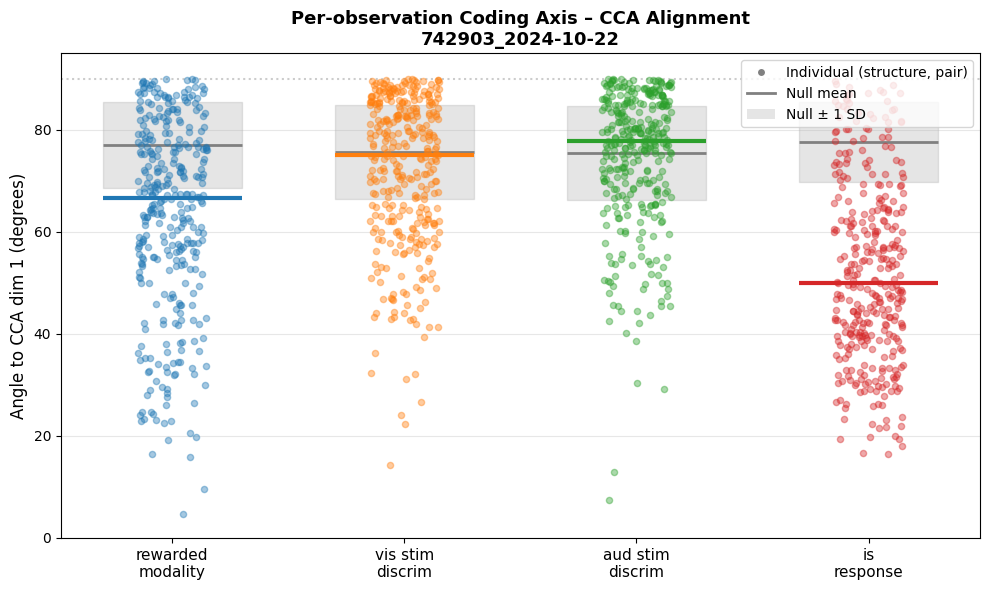

In [63]:
# ── Catplot: observed angle vs CCA dim 1, coloured by structure, per variable ──
# Strip plot so every (structure, pair) observation is visible.

fig, ax = plt.subplots(figsize=(10, 6))

colors = {'rewarded_modality': '#1f77b4', 'vis_stim_discrim': '#ff7f0e',
          'aud_stim_discrim': '#2ca02c', 'is_response': '#d62728'}

for i, var_name in enumerate(var_names):
    sub = angles_df[angles_df['variable'] == var_name]
    jitter = np.random.uniform(-0.15, 0.15, size=len(sub))
    
    # Observed
    ax.scatter(
        np.full(len(sub), i) + jitter,
        sub['observed_angle_deg'],
        alpha=0.4, s=20, color=colors[var_name], zorder=3,
    )
    # Null mean ± 1 std band
    null_mean = sub['null_mean_deg'].mean()
    null_std = sub['null_std_deg'].mean()
    ax.fill_between(
        [i - 0.3, i + 0.3], null_mean - null_std, null_mean + null_std,
        color='gray', alpha=0.2, zorder=1,
    )
    ax.hlines(null_mean, i - 0.3, i + 0.3, color='gray', linewidth=2, zorder=2)
    
    # Median observed
    obs_median = sub['observed_angle_deg'].median()
    ax.hlines(obs_median, i - 0.3, i + 0.3, color=colors[var_name],
              linewidth=3, zorder=4)

ax.set_xticks(range(len(var_names)))
ax.set_xticklabels(var_labels, fontsize=11)
ax.set_ylabel('Angle to CCA dim 1 (degrees)', fontsize=12)
ax.set_title(f'Per-observation Coding Axis – CCA Alignment\n{session_id}',
             fontsize=13, fontweight='bold')
ax.set_ylim([0, 95])
ax.axhline(90, color='gray', linestyle=':', alpha=0.4)
ax.grid(axis='y', alpha=0.3)

from matplotlib.lines import Line2D
legend_elems = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
           markersize=6, label='Individual (structure, pair)'),
    Line2D([0], [0], color='gray', linewidth=2, label='Null mean'),
    Patch(facecolor='gray', alpha=0.2, label='Null ± 1 SD'),
]
ax.legend(handles=legend_elems, fontsize=10, loc='upper right')

plt.tight_layout()
plt.show()

In [64]:
# ── Save coding-axis–CCA angle results ─────────────────────────────────────────
angles_path = output_dir / f'cca_coding_angles_{session_id}.parquet'
angles_df.assign(session_id=session_id).to_parquet(angles_path, index=False)

best_path = output_dir / f'cca_best_aligned_{session_id}.parquet'
best_aligned.assign(session_id=session_id).to_parquet(best_path, index=False)

print(f"Saved angle results     → {angles_path}")
print(f"Saved best-aligned table → {best_path}")

Saved angle results     → ..\results\cca\cca_coding_angles_742903_2024-10-22.parquet
Saved best-aligned table → ..\results\cca\cca_best_aligned_742903_2024-10-22.parquet
